# 003. 位置エンコーディング(Positional Encoding)/ RoPE

**分類の枠組みから RoPE(Rotary Position Embedding)の導出まで**
*From a Unified Taxonomy of Positional Encoding to the Derivation of RoPE*

`theories/01_foundations/003_positional_encoding_rope.ipynb`

## 1. 概要 / Overview

[002](./002_transformer_block.ipynb) では、Transformer Block(多頭注意機構と順伝播ネットワークの組み合わせ)が単体では入力の並び替えに対して置換同変(permutation equivariant)であることを述べ、系列の順序情報を与えるために正弦波(sinusoidal)方式の位置エンコーディング(Positional Encoding)を暫定的に導入した。

本ノートブックでは、位置情報をどこに・どのように注入するかで方式を統一的に分類したうえで、学習可能な絶対位置埋め込み(Learned Absolute Positional Embedding)・相対位置エンコーディング(Relative Positional Encoding、Shaw et al. 方式・T5 の相対位置バイアス)・ALiBi(Attention with Linear Biases)・RoPE(Rotary Position Embedding)を数式レベルで比較する。中心となるのは RoPE の数学的導出であり、「Query・Key の内積が相対位置のみに依存する」という要請から回転行列による解を導き、効率的な実装まで扱う。

学習を伴う実験では、可変長の copy task を用いて各方式の学習長内での表現力(実験 B-1)と、学習長を超える外挿(length extrapolation)性能(実験 B-2)を分けて評価する。

## 2. 参考論文 / References

| # | 著者 / Authors | タイトル / Title | 会議・媒体 / Venue | URL |
|---|---|---|---|---|
| [1] | Vaswani, Shazeer, Parmar, Uszkoreit, Jones, Gomez, Kaiser, Polosukhin | Attention Is All You Need | NeurIPS 2017 | https://arxiv.org/abs/1706.03762 |
| [2] | Devlin, Chang, Lee, Toutanova | BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding | NAACL 2019 | https://arxiv.org/abs/1810.04805 |
| [3] | Shaw, Uszkoreit, Vaswani | Self-Attention with Relative Position Representations | NAACL 2018 | https://arxiv.org/abs/1803.02155 |
| [4] | Raffel, Shazeer, Roberts, Lee, Narang, Matena, Zhou, Li, Liu | Exploring the Limits of Transfer Learning with a Unified Text-to-Text Transformer | JMLR 2020 | https://arxiv.org/abs/1910.10683 |
| [5] | Press, Smith, Lewis | Train Short, Test Long: Attention with Linear Biases Enables Input Length Extrapolation | ICLR 2022 | https://arxiv.org/abs/2108.12409 |
| [6] | Su, Lu, Pan, Murtadha, Wen, Liu | RoFormer: Enhanced Transformer with Rotary Position Embedding | Neurocomputing 2024 | https://arxiv.org/abs/2104.09864 |
| [7] | Haviv, Ram, Press, Izsak, Levy | Transformer Language Models without Positional Encodings Still Learn Positional Information | Findings of EMNLP 2022 | https://arxiv.org/abs/2203.16634 |

- **[1] が正弦波方式の原典**(原論文の 3.5 節)であり、002 で暫定導入した方式に対応する。
- [2] は学習可能な絶対位置埋め込みの代表例(BERT)として参照する。
- [3] は Shaw et al. 方式の相対位置エンコーディングの原典。
- [4] は T5 の相対位置バイアス(原論文の 2.1 節)の原典。
- [5] は ALiBi の原典。原論文タイトルの "Train Short, Test Long" が示す通り、外挿を明示的な設計目標とする。
- **[6] が本トピックの中心である RoPE の原典**。原論文の 2 節の要請の定式化・3 節の導出・3.4.3 節の遠距離減衰の議論に基づく。
- [7] は、位置エンコーディングを一切持たない因果的な言語モデルであっても位置情報を獲得できることを報告する。実験 B の対照群(位置エンコーディングなし)の精度を解釈する際に参照する(3.1 節)。

## 3. 理論 / Theory

**表記の約束**: 本ノートブックでも 002 と同様、系列を行方向に並べた行ベクトル規約を用いる。

**記号 / Notation**(本セクション全体で共通)

| 記号 | 意味 |
|---|---|
| $L$ | 系列長 |
| $d_{\text{model}}$ | モデル次元 |
| $h$ | ヘッド数 |
| $d_k = d_{\text{model}} / h$ | ヘッドあたりの次元 |
| $m$ | Query 側の位置インデックス |
| $n$ | Key 側の位置インデックス |

### 3.1 動機・課題 / Motivation

001 で見た通り、Scaled Dot-Product Attention は $e_{mn} = q_m^{\top} k_n / \sqrt{d_k}$ という **すべての位置対に対称な** 演算であり、入力の行を並び替えると出力の行も同じように並び替わる(置換同変)。したがって Attention・順伝播ネットワークだけを積み重ねても、系列が「どの順序で並んでいるか」を区別できない(002・3.6 節で述べた通り。ただし因果マスクを課す場合については後述する)。

002 では、この問題への対処として正弦波(sinusoidal)方式を **ひとまずブロックの構造を検証するための足場** として暫定導入した。本トピックでは一歩進んで、そもそもどのような位置情報の注入方式がありうるのか、現代の大規模言語モデルがなぜ特定の方式(多くの場合 RoPE)を採用するのかを扱う。

**因果マスクとの関係について**: 上記の置換同変性の議論は、すべての位置対を対称に扱う場合(双方向の自己注意)に厳密に成り立つ。しかし、本ノートブックの実験 B が用いる **因果マスク付き decoder-only 構成** では話が異なる。因果マスクの下では、位置 $m$ の Query が参照できる Key の集合は $\{0, \dots, m\}$ に制限され、**位置ごとに参照可能なトークンの数(集合のサイズ)が異なる**。この非対称性そのものが暗黙の位置情報の一種であり、因果的な自己注意は厳密には置換同変ではない。実際、位置エンコーディングを一切持たない因果的な言語モデルであっても位置情報を獲得することが報告されている(Haviv et al. [7])。したがって、実験 B の対照群(位置エンコーディングなし)は「位置情報がゼロ」の条件ではなく、「明示的な位置エンコーディングを持たない」条件として解釈する必要がある(この点は実験 B-1 の対照群の精度の解釈に直結する、6.2 節参照)。

もう 1 つの重要な課題が **長さの外挿(length extrapolation)** である。学習時に見た最大系列長を超える入力に対して、モデルがどこまで性能を保てるかは方式によって大きく異なる。この観点は実験 B-2 で扱う。

### 3.2 位置情報の注入点による分類 / Taxonomy by Injection Point

位置情報をどこに注入するかで、各方式は次の 3 グループに分類できる。

| 注入点 | 該当方式 | 絶対 / 相対 |
|---|---|---|
| 入力埋め込みへの加算 | 正弦波、学習可能な絶対位置埋め込み | 絶対位置 |
| Query・Key の線形射影後、内積を取る前の変換 | RoPE | 相対位置(絶対位置 $m$ を作用させるが、内積は相対位置 $n-m$ のみに依存する) |
| Attention スコアへの加算 | Shaw et al. 方式、T5 の相対位置バイアス、ALiBi | 相対位置 |

```mermaid
flowchart TB
    ROOT["位置情報の注入方式"]
    ROOT --> ABS["絶対位置を符号化"]
    ROOT --> REL["相対位置を符号化"]

    ABS --> EMB["入力埋め込みへの加算"]
    EMB --> SIN["正弦波方式<br/>(Vaswani et al. [1])"]
    EMB --> LAPE["学習可能な絶対位置埋め込み<br/>(BERT [2])"]

    REL --> QK["Query・Key の変換<br/>(内積を取る前)"]
    QK --> ROPE["RoPE<br/>(Su et al. [6])"]

    REL --> BIAS["Attention スコアへの加算"]
    BIAS --> SHAW["Shaw et al. 方式<br/>([3])"]
    BIAS --> T5B["T5 の相対位置バイアス<br/>([4])"]
    BIAS --> ALIBI["ALiBi<br/>(Press et al. [5])"]
```

この分類は 4 節「実装方針」のインターフェース設計(`QueryKeyPositionalTransform`と`AttentionScoreBias`の 2 種類)と対応する。図がなくても、以下の数式・文章だけで各方式の位置づけは理解できる。

### 3.3 正弦波方式の再訪 / Sinusoidal Positional Encoding Revisited

002・3.6 節で、正弦波方式は次元ペア $(2i, 2i+1)$ ごとに周波数 $\omega_i = 1/10000^{2i/d_{\text{model}}}$ の正弦波を割り当てており、固定オフセット $k$ だけ位置をずらす操作が

$$
\mathrm{PE}(\mathrm{pos}+k) = M_i(k) \, \mathrm{PE}(\mathrm{pos})
$$

という、$\mathrm{pos}$ に依存せず $k$ だけで決まる $2\times2$ 回転行列 $M_i(k)$ で表現できることを導出した(角度 $k \omega_i$ の回転行列)。

この「固定オフセットが位置に依存しない回転行列で表現できる」という性質は、後述する RoPE の回転行列 $R(m\theta)$ と数学的に同じ構造を持つ。**両者の決定的な違いは、この回転をどこに作用させるかである**:

- **正弦波方式**: 回転(に相当する正弦波パターン)を **トークン埋め込みに加算する**。回転行列 $M_i(k)$ は埋め込み空間上の性質として導出される副産物であり、Attention の内積計算そのものには回転として現れない。
- **RoPE**: 回転を **Query・Key そのものに作用させる**(内積を取る直前に $R(m\theta)$ を乗じる)。この結果、内積 $(R(m\theta)q)^{\top}(R(n\theta)k)$ は相対位置 $n-m$ のみに依存する形に **必然的に** なる(3.8 節で厳密に導出する)。加算ではなく回転という **乗法的** な作用にすることで、この相対位置への依存が「たまたま成り立つ性質」ではなく「設計上保証される性質」になる。

以下、この違いを起点に、各方式を数式で見ていく。

### 3.4 学習可能な絶対位置埋め込み(Learned Absolute Positional Embedding)

**定義**: 学習可能な行列 $P \in \mathbb{R}^{L_{\max} \times d_{\text{model}}}$ を用意し、位置 $m$ のトークン埋め込みに $P_m$(行列 $P$ の $m$ 行目)を加算する。$L_{\max}$ は学習時に定めた最大系列長。BERT [2] などが採用する。

$$
x_m \leftarrow x_m + P_m
$$

**パラメータ数**: $d_{\text{model}} \cdot L_{\max}$ に比例する(正弦波方式はパラメータを持たない)。

**外挿性**: $P$ は $L_{\max}$ 行しか持たないため、$m \ge L_{\max}$ に対応する行が存在しない。**原理的に外挿できない**(実験 B-2 で、この制約を実際に超えた場合の挙動を確認する)。

### 3.5 Shaw et al. 方式の相対位置エンコーディング

Attention スコアを次のように定義する [3]:

$$
e_{mn} = \frac{(x_m W^Q)(x_n W^K + a^K_{mn})^{\top}}{\sqrt{d_k}}, \qquad
a^K_{mn} = w^K_{\mathrm{clip}(n-m,\ k_{\text{clip}})}
$$

- $\mathrm{clip}(x, k) = \max(-k, \min(k, x))$ は相対距離を $[-k_{\text{clip}}, k_{\text{clip}}]$ に切り詰める関数。$k_{\text{clip}}$ より遠い相対距離はすべて境界値として扱われる(「これ以上遠い」という情報だけが残る)。
- $w^K \in \mathbb{R}^{(2k_{\text{clip}}+1) \times d_k}$ が学習可能パラメータで、相対距離のバケット数($2k_{\text{clip}}+1$ 通り)に比例する。

上式を展開すると

$$
e_{mn} = \underbrace{\frac{q_m^{\top} k_n}{\sqrt{d_k}}}_{\text{通常の Attention スコア}} + \underbrace{\frac{q_m^{\top} a^K_{mn}}{\sqrt{d_k}}}_{\text{相対位置バイアス項}}
$$

となり、第 2 項は Query の内容 $q_m$ と相対位置ベクトル $a^K_{mn}$ の内積である。この項は $q_m$ に依存するため、位置のみに依存する「スコアへのバイアス」という枠組み(T5・ALiBi と共通のインターフェース)には厳密には収まらない(詳細は 4 節)。

**原論文は Value 側にも同様の項を加算する定式化を持つ**:

$$
z_m = \sum_n a_{mn} (v_n + a^V_{mn}), \qquad a^V_{mn} = w^V_{\mathrm{clip}(n-m,\ k_{\text{clip}})}
$$

この項は Attention 重み $a_{mn}$ による Value の集約そのものに介入するため、「スコアへのバイアス」という枠組みには収まらない。後続研究では、この Value 側の項は寄与が小さいとして省略されることが多い。本ノートブックでは 5.5 節で、この項を直接実装し、Key 側のみの場合との差を小規模な数値例で確認する。

### 3.6 T5 の相対位置バイアス

T5 [4] は、Attention スコアにヘッドごとに学習可能な **スカラー** $b_{h,\, \mathrm{bucket}(n-m)}$ を加算する:

$$
e_{mn} = \frac{q_m^{\top} k_n}{\sqrt{d_k}} + b_{h,\, \mathrm{bucket}(n-m)}
$$

相対距離 $n-m$ は $\mathrm{bucket}(\cdot)$ によってバケット化される。バケット化は次の考え方に基づく:

- 近距離(絶対値が小さい相対距離)は **線形スケール** でバケットに割り当て、1 だけ違う距離も別のバケットとして区別する。
- 遠距離は **対数スケール** でバケットに割り当て、大きく異なる距離をまとめて 1 つのバケットにする。これにより、任意の遠さの相対距離もバケット数の上限内に収まる。
- 双方向(Encoder の自己注意)の場合はバケット数を前半・後半で 2 分割し、$n>m$ と $n<m$ を区別する。因果的(Decoder の自己注意)の場合は $n \le m$ のみを考えればよいため、全バケットを片側に使う。

**Shaw et al. 方式との違い**:

| | Shaw et al. 方式 | T5 |
|---|---|---|
| 加算する項 | ベクトル $a^K_{mn} \in \mathbb{R}^{d_k}$(Query との内積が必要) | スカラー $b_{h,\, \mathrm{bucket}(n-m)}$ |
| 相対距離の扱い | クリップ(境界を超えると一定値) | 対数バケット化(境界を超えても粗く区別) |
| 層間の共有 | 層ごとに独立が一般的 | 原論文では層間で共有されることが多いが、本ノートブックの実験では層ごとに独立した`T5RelativePositionBias`インスタンスを持たせている(4 節参照) |

### 3.7 ALiBi(Attention with Linear Biases)

ALiBi [5] は、Attention スコアに **学習可能パラメータを持たない** 線形バイアスを加算する:

$$
e_{mn} = \frac{q_m^{\top} k_n}{\sqrt{d_k}} - m_h \cdot (m - n)
$$

$m_h$ はヘッド $h$ ごとに固定された傾き(slope)で、幾何数列として次のように定める(ヘッド数を $H$ とする):

$$
m_h = 2^{-8h/H} \qquad (h = 1, \dots, H)
$$

例えば $H=8$ なら傾きは $2^{-1}, 2^{-2}, \dots, 2^{-8}$ という等比数列になる。傾きが小さいヘッドは遠い位置まで緩やかに減衰するバイアスを持ち(遠距離を見渡す担当)、傾きが大きいヘッドは近い位置に強く減衰するバイアスを持つ(近距離に集中する担当)。ヘッドごとに異なる距離スケールを担当させることで、単一の減衰スケールでは表現しきれない多様な距離依存性をカバーする。

学習可能パラメータを一切持たないため、$m_h$ は系列長によらず定義でき、**任意の系列長にそのまま適用できる**。原論文のタイトル "Train Short, Test Long" が示す通り、外挿性能を明示的な設計目標としている。$H$ が 2 のべき乗でない場合、原論文は直近の 2 のべき乗で計算した傾きを補間して残りのヘッド分を埋めるという別の定め方をしており、`ALiBiPositionBias._compute_slopes`(5.3 節)もこの原論文の公式実装に従っている。

### 3.8 RoPE(Rotary Position Embedding)

本トピックの中心。Su et al. [6] の導出を追う。

#### 3.8.1 要請の定式化

位置 $m$ の Query と位置 $n$ の Key を作る関数 $f_q(x_m, m)$, $f_k(x_n, n)$ について、その内積が **相対位置のみに依存する** ことを要請する:

$$
\langle f_q(x_m, m),\ f_k(x_n, n) \rangle = g(x_m, x_n,\ m-n)
$$

すなわち、$m, n$ 自体ではなく差 $m-n$ だけが内積に影響するような $f_q, f_k$ を探すという問題設定である($g$ は任意関数なので、以降の導出では符号を反転した $n-m$ の形で表しても要請自体は変わらない)。

#### 3.8.2 2 次元の場合の解

$d_k=2$ の場合、回転行列

$$
R(\theta) = \begin{pmatrix} \cos\theta & -\sin\theta \\ \sin\theta & \cos\theta \end{pmatrix}
$$

を用いて $f_q(x_m, m) = R(m\theta)\,(W^Q x_m)$、$f_k(x_n, n) = R(n\theta)\,(W^K x_n)$ と定めると、回転行列の直交性 $R(\theta)^{\top} = R(-\theta)$ と加法定理 $R(\alpha)R(\beta) = R(\alpha+\beta)$ から

$$
R(m\theta)^{\top} R(n\theta) = R(-m\theta) R(n\theta) = R((n-m)\theta)
$$

が成り立つ。したがって

$$
\langle R(m\theta) q,\ R(n\theta) k \rangle = q^{\top} R(m\theta)^{\top} R(n\theta)\, k = q^{\top} R((n-m)\theta)\, k
$$

となり、内積は相対位置 $n-m$ のみの関数になる。これが 3.8.1 節の要請を満たす具体解である。

#### 3.8.3 複素数表現

2 次元の回転は複素数の乗算として書ける。$q = W^Q x_m$ を複素数 $q_{\mathbb{C}} \in \mathbb{C}$ とみなすと

$$
f_q(x_m, m) = (W^Q x_m)\, e^{i m \theta}
$$

であり、角度 $m\theta$ だけ回転させる操作そのものである(オイラーの公式 $e^{i\alpha} = \cos\alpha + i\sin\alpha$ が 3.8.2 節の回転行列に対応する)。

#### 3.8.4 $d_k$ 次元への一般化

$d_k$ 次元の Query・Key を $d_k/2$ 個の 2 次元部分空間に分割し、部分空間 $i$ ($i=0, \dots, d_k/2-1$)に角周波数

$$
\theta_i = \mathrm{base}^{-2i/d_k}
$$

の回転を適用する。$\mathrm{base}$ の既定値は $10000$(正弦波方式と同じ値)。$\mathrm{base}$ は部分空間ごとの回転速度の分布を決めるパラメータであり、$i$ が小さい(低次元インデックス)部分空間ほど速く回転し(高周波)、$i$ が大きい部分空間ほどゆっくり回転する(低周波)。この分布は $\mathrm{base}$ を変えることで調整でき、これが長文脈拡張(トピック 014)のスケーリング手法群(NTK-aware スケーリング・YaRN など)の出発点になる。

全部分空間の回転をまとめたブロック対角行列を $R_{\Theta,m}$ とする:

$$
R_{\Theta,m} = \begin{pmatrix}
R(m\theta_0) & & \\
& \ddots & \\
& & R(m\theta_{d_k/2-1})
\end{pmatrix} \in \mathbb{R}^{d_k \times d_k}
$$

#### 3.8.5 内積が相対位置のみに依存することの証明

$R_{\Theta,m}$ はブロック対角行列であり、各ブロックが直交行列 $R(m\theta_i)$ なので、転置との積もブロックごとに独立に計算できる:

$$
R_{\Theta,m}^{\top} R_{\Theta,n} =
\begin{pmatrix}
R(m\theta_0)^{\top} R(n\theta_0) & & \\
& \ddots & \\
& & R(m\theta_{d_k/2-1})^{\top} R(n\theta_{d_k/2-1})
\end{pmatrix}
= R_{\Theta,\, n-m}
$$

(各ブロックに 3.8.2 節の関係を適用した)。したがって

$$
(R_{\Theta,m}\, q)^{\top} (R_{\Theta,n}\, k) = q^{\top} R_{\Theta,m}^{\top} R_{\Theta,n}\, k = q^{\top} R_{\Theta,\, n-m}\, k
$$

となり、回転後の Query・Key の内積は相対位置 $n-m$ のみに依存する(3.8.1 節の要請を $d_k$ 次元で満たす)。

#### 3.8.6 遠距離減衰(long-term decay)

RoPE には、相対距離 $|n-m|$ が大きくなるにつれて内積の絶対値の上界が減衰するという性質がある。厳密な証明には Abel 変換による上界の評価が必要であり、本ノートブックでは立ち入らない(原論文 [6] の 3.4.3 節を参照)。この傾向は実験 A-4 でランダムな Query・Key に対する内積を相対距離の関数として数値的に確認する。

#### 3.8.7 効率的な実装

ブロック対角行列 $R_{\Theta,m}$ との明示的な行列積は $O(d_k^2)$ かかり非効率である。実務上は、次元を前半・後半に 2 分割して要素を入れ替える演算 $\mathrm{rotate\_half}$ と、$\cos$・$\sin$ の要素ごとの積(ブロードキャスト)で等価な計算を行う($[q_1, q_2]$ をそれぞれ $d_k/2$ 次元の前半・後半とする):

$$
\mathrm{rotate\_half}([q_1, q_2]) = [-q_2, q_1]
$$

$$
R_{\Theta,m}\, q \;\;\hat{=}\;\; q \odot \cos(m\boldsymbol{\theta}) + \mathrm{rotate\_half}(q) \odot \sin(m\boldsymbol{\theta})
$$

ここで $\boldsymbol{\theta} = [\theta_0, \dots, \theta_{d_k/2-1}, \theta_0, \dots, \theta_{d_k/2-1}]$($\theta_i$ を前半・後半に複製したベクトル)、$\odot$ は要素ごとの積である。この実装は次元ペアの取り方(部分空間 $i$ を何番目と何番目の次元に対応させるか)が 3.8.4 節のブロック対角行列と異なる($i$ 番目と $i+d_k/2$ 番目を組にする、GPT-NeoX / LLaMA 系の実装で広く使われる変形)が、Query と Key に **同一の置換** を適用するため、3.8.5 節の相対位置のみへの依存という性質は保たれる。この等価性は実験 A-3a で数値的に検証する。

隣接ペアの取り方(3.8.4 節)と前半・後半ペアの取り方(本節)は、座標の固定置換 $P$ によって $R^{\text{half}}_{\Theta,m} = P^{\top} R^{\text{interleaved}}_{\Theta,m} P$ と厳密に結ばれている(実験 A-3c で数値的に確認する)。この置換は線形射影 $W^Q, W^K$ の再パラメータ化(列の並べ替え)に吸収されるため、**モデルの表現力としては両者は等価** である。ただし置換を揃えずに同一の $q, k$ を両方の取り方で回転させると、内積の値そのものは一致しない(実験 A-3b で確認する)。

#### 3.8.8 適用対象

RoPE は **Query と Key のみに適用し、Value には適用しない**。RoPE の狙いは「内積という演算そのものに相対位置を持ち込む」ことであり、Value は Attention 重みによる加重平均の対象であって内積の計算には関与しないため、回転を適用する対象にならない。

### 3.9 アルゴリズム / Algorithm

#### RoPE: 角周波数の事前計算と適用

```text
入力: d_k(偶数)、base(既定 10000)、事前計算する最大位置 P
出力: cos, sin ∈ R^{P × d_k}

1: theta_i ← base^(-2i/d_k)                     (i = 0, ..., d_k/2 - 1)
2: freqs[m, i] ← m * theta_i                     (m = 0, ..., P-1)
3: emb ← concat(freqs, freqs, axis=-1)           (d_k/2 を複製して d_k に)
4: cos ← cos(emb), sin ← sin(emb)

# Query・Key への適用(位置 m の q、位置 n の k、それぞれ独立に)
5: rotate_half(x) ← concat(-x[d_k/2:], x[:d_k/2])
6: q' ← q * cos[m] + rotate_half(q) * sin[m]
7: k' ← k * cos[n] + rotate_half(k) * sin[n]
```

#### 相対位置バイアス行列の構築(Shaw et al. / T5 / ALiBi 共通の枠組み)

```text
入力: S_q, S_k(Query 側・Key 側の系列長)
出力: bias ∈ R^{h × S_q × S_k}(または (1, S_q, S_k))

1: m ← arange(S_q), n ← arange(S_k)
2: relative_position[m, n] ← n - m

# Shaw et al. 方式(a^K_mn のみを返し、Query との内積は呼び出し側で計算する)
3a: index ← clip(relative_position, -k_clip, k_clip) + k_clip
4a: a_K[m, n] ← w_K[index[m, n]]                 (呼び出し側で q_m と内積を取る)

# T5
3b: bucket[m, n] ← relative_position_bucket(relative_position[m, n])
4b: bias[h, m, n] ← b[h, bucket[m, n]]

# ALiBi
3c: slopes[h] ← 2^(-8h/H)                        (h = 1, ..., H)
4c: bias[h, m, n] ← slopes[h] * relative_position[m, n]
```

## 4. 実装方針 / Implementation Plan

### `src/`に切り出すもの

`src/layers/positional_encoding.py`に、注入点に応じた 2 種類の抽象基底クラスと、各方式の実装クラスを追加する(`SinusoidalPositionalEncoding`はそのまま残す)。

| クラス | 役割 | 注入点(3.2 節) |
|---|---|---|
| `QueryKeyPositionalTransform`(抽象基底クラス) | `apply(query, key, positions=None) -> (query, key)` | Query・Key の変換 |
| `RotaryPositionEmbedding` | 上記の実装。RoPE(3.8 節) | 同上 |
| `AttentionScoreBias`(抽象基底クラス) | `bias(query_length, key_length, device, dtype) -> Tensor` | スコアへの加算 |
| `T5RelativePositionBias` | 上記の実装。T5(3.6 節) | 同上 |
| `ALiBiPositionBias` | 上記の実装。ALiBi(3.7 節) | 同上 |
| `ShawRelativePositionBias` | `AttentionScoreBias` を継承するが、`bias()` ではなく `relative_vectors()` を主に使う(下記の設計判断を参照) | 同上(ただし特別扱い) |
| `LearnedAbsolutePositionalEmbedding` | `forward(x, positions=None) -> x` | 入力埋め込みへの加算 |

`positions`引数はいずれも、指定しない場合は $0$ から系列長 $-1$ までの連番として扱う任意引数である。これを外部から渡せるようにしている理由は、KV キャッシュを用いた逐次推論(トピック 010)では、生成の各ステップで Query の絶対位置がキャッシュ長だけずれるため、位置インデックスを明示的に指定できる必要があるからである。

**`ShawRelativePositionBias`に関する設計判断**: 3.5 節で見た通り、Shaw et al. 方式の Key 側の項 $a^K_{mn}$ は Query の内容 $q_m$ と内積を取るため、位置のみに依存する`bias(query_length, key_length, device, dtype)`という統一インターフェース(T5・ALiBi と共通)では計算できない。そこで`ShawRelativePositionBias`は`AttentionScoreBias`を継承しつつ、`bias()`は使用不可であることを示す例外を送出し、代わりに相対位置ベクトル $a^K_{mn}$ のみを返す`relative_vectors(query_length, key_length, device, dtype) -> Tensor`(形状`(S_q, S_k, d_k)`)を提供する。`MultiHeadAttention`側で`isinstance`判定を行い、このクラスの場合だけ Query との内積 $q_m \cdot a^K_{mn}$ を直接計算する特別扱いを 1 箇所だけ追加する。

`src/layers/attention.py`の`MultiHeadAttention`は、既存の引数・挙動を変えずに拡張する:

- コンストラクタに`positional_transform: QueryKeyPositionalTransform | None = None`と`attention_score_bias: AttentionScoreBias | None = None`を追加する(両方とも既定値`None`)。
- `forward`に`positions: Tensor | None = None`を追加する。
- 引数が渡されたときだけ、対応する処理を Attention 計算の該当箇所(Query・Key の線形射影の直後、スコアの softmax の直前)に挟む。
- `scaled_dot_product_attention()`にも`bias: Tensor | None = None`を追加し、スケーリング後のスコアに加算できるようにする。

**後方互換性**: これらの引数をすべて省略した場合、001・002 のノートブックは一切変更なく、同一 seed で完全に同一の数値を出力する。実際に両ノートブックを再実行して数値を比較し、5.1 節末尾で結果を報告する。

`src/layers/transformer_block.py`(`EncoderBlock`)は変更しない。実験 B では`EncoderBlock`を構築した後、その`self_attn`属性を`positional_transform`/`attention_score_bias`を指定した`MultiHeadAttention`に差し替えることで、`EncoderBlock`の残差接続・層正規化・順伝播ネットワークの構造をそのまま再利用する。

### ノートブック内に直接書くもの

- Shaw et al. 方式の **Value 側の項** $a^V_{mn}$(3.5 節)。スコアへのバイアスという枠組みに収まらず(Value の集約に直接介入するため)、`src/`のインターフェースからは意図的に外している。5.5 節で短い検証コードとして直接実装し、Key 側のみの場合との数値的な差を確認する。
- 実験 B・C 用の可変長 copy task のデータ生成、モデル定義、学習ループ、評価コード。

## 5. 実装 / Implementation

### 5.1 環境セットアップ

In [1]:
# 環境セットアップ(Google Colab)
# Colab 上でのみリポジトリを clone し、リポジトリルートをカレントディレクトリにする。
# ローカル(Jupyter)実行時は、リポジトリルートで起動していればそのまま動く。
import sys

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    !git clone https://github.com/kojikojiprg/ai-theories.git
    %cd ai-theories
    !pip install uv -q
    !uv pip install --system -r requirements.txt -q

In [2]:
# `from src...` の絶対 import が通るように、リポジトリルートを sys.path に追加する。
# (ノートブックを theories/01_foundations/ から直接開いた場合の保険)
import os
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / "src").exists():  # theories/01_foundations/ から起動した場合
    ROOT = ROOT.parents[1]
    os.chdir(ROOT)
sys.path.insert(0, str(ROOT))

In [3]:
import inspect
import math
import time

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn

from src.layers import (
    ALiBiPositionBias,
    EncoderBlock,
    LearnedAbsolutePositionalEmbedding,
    MultiHeadAttention,
    RotaryPositionEmbedding,
    ShawRelativePositionBias,
    SinusoidalPositionalEncoding,
    T5RelativePositionBias,
    create_causal_mask,
)
from src.utils.visualization import plot_attention_heatmap

SEED = 0
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"device: {DEVICE}")

device: cpu


**001・002 の後方互換性の確認について**:`MultiHeadAttention`に`positional_transform`/`attention_score_bias`/`positions`を追加するにあたり、これらをすべて省略した場合に 001・002 が変更前と完全に同一の数値を出力することを、本ノートブックの作成過程で別途確認済みである(`jupyter nbconvert --execute`で両ノートブックを変更前後で再実行し、損失・精度・パラメータ数などの全出力を比較した。壁時計時間の実測値のみ実行環境依存で異なり、それ以外の数値はすべて一致した)。作業報告にもこの確認結果を明記する。

### 5.2 RoPE(Rotary Position Embedding)の実装確認

In [4]:
print(inspect.getsource(RotaryPositionEmbedding.apply))

    def apply(
        self, query: Tensor, key: Tensor, positions: Tensor | None = None
    ) -> tuple[Tensor, Tensor]:
        seq_len = query.size(-2)
        if positions is None:
            positions = torch.arange(seq_len, device=query.device)

        max_pos = int(positions.max().item()) + 1
        if max_pos > self.max_position:
            self._build_cache(max_pos)

        cos = self.cos_cached[positions].to(dtype=query.dtype, device=query.device)
        sin = self.sin_cached[positions].to(dtype=query.dtype, device=query.device)

        q = query * cos + self._rotate_half(query) * sin
        k = key * cos + self._rotate_half(key) * sin
        return q, k



In [5]:
D_K_DEMO = 8
rope_demo = RotaryPositionEmbedding(D_K_DEMO, max_position=32)
print(f"cos_cached の形状: {tuple(rope_demo.cos_cached.shape)}")

q_demo = torch.randn(1, 1, 5, D_K_DEMO)
k_demo = torch.randn(1, 1, 5, D_K_DEMO)
q_rot, k_rot = rope_demo.apply(q_demo, k_demo)
print(f"適用後の形状: query={tuple(q_rot.shape)}, key={tuple(k_rot.shape)}")
print(
    f"位置 0 では回転角が 0 なので、適用前後で一致する: "
    f"{torch.allclose(q_demo[:, :, 0], q_rot[:, :, 0])}"
)

cos_cached の形状: (32, 8)
適用後の形状: query=(1, 1, 5, 8), key=(1, 1, 5, 8)
位置 0 では回転角が 0 なので、適用前後で一致する: True


### 5.3 相対位置バイアス(Shaw et al. 方式・T5・ALiBi)の実装確認

In [6]:
print(inspect.getsource(ALiBiPositionBias._compute_slopes))

    @staticmethod
    def _compute_slopes(num_heads: int) -> list[float]:
        """m_h = 2^(-8h/H) の幾何数列を計算する。

        H が 2 のべき乗でない場合は、原論文の公式実装に従い、直近の 2 のべき乗
        で計算した数列を補間して残りのヘッド分を埋める。
        """

        def _power_of_2_slopes(n: int) -> list[float]:
            start = 2.0 ** (-8.0 / n)
            return [start ** (h + 1) for h in range(n)]

        if math.log2(num_heads).is_integer():
            return _power_of_2_slopes(num_heads)

        closest_pow2 = 2 ** math.floor(math.log2(num_heads))
        base_slopes = _power_of_2_slopes(closest_pow2)
        extra_slopes = _power_of_2_slopes(2 * closest_pow2)[0::2][: num_heads - closest_pow2]
        return base_slopes + extra_slopes



In [7]:
for h in (4, 8):
    slopes = ALiBiPositionBias(h).slopes
    print(f"H={h}: slopes = {[round(s, 5) for s in slopes.tolist()]}")

H=4: slopes = [0.25, 0.0625, 0.01562, 0.00391]
H=8: slopes = [0.5, 0.25, 0.125, 0.0625, 0.03125, 0.01562, 0.00781, 0.00391]


In [8]:
t5_demo = T5RelativePositionBias(num_heads=4, num_buckets=16, max_distance=32, bidirectional=False)
bias_demo = t5_demo.bias(query_length=6, key_length=6, device="cpu", dtype=torch.float32)
print(f"T5 相対位置バイアスの形状: {tuple(bias_demo.shape)}")
print("head=0 のバイアス行列(下三角、因果的なので n <= m のみ意味を持つ):")
print(bias_demo[0].detach().numpy().round(3))

T5 相対位置バイアスの形状: (4, 6, 6)
head=0 のバイアス行列(下三角、因果的なので n <= m のみ意味を持つ):
[[ 1.698  1.698  1.698  1.698  1.698  1.698]
 [ 2.03   1.698  1.698  1.698  1.698  1.698]
 [ 0.184  2.03   1.698  1.698  1.698  1.698]
 [-0.17   0.184  2.03   1.698  1.698  1.698]
 [-0.442 -0.17   0.184  2.03   1.698  1.698]
 [ 1.181 -0.442 -0.17   0.184  2.03   1.698]]


因果的(`bidirectional=False`)なバケット化のため、$n > m$(未来を参照する側)はすべて同じバケット(バケット 0)に潰れており、値も同一になっている。これは因果マスクによってどのみち参照されない領域なので実害はない。

### 5.4 位置エンコーディングを統合した`MultiHeadAttention`の確認

In [9]:
print(inspect.getsource(MultiHeadAttention.forward))

    def forward(
        self,
        query: Tensor,
        key: Tensor,
        value: Tensor,
        mask: Tensor | None = None,
        positions: Tensor | None = None,
    ) -> tuple[Tensor, Tensor]:
        """Multi-Head Attention の順伝播。

        Args:
            query: 形状 ``(B, S_q, d_model)``。
            key: 形状 ``(B, S_k, d_model)``。
            value: 形状 ``(B, S_k, d_model)``。
                自己注意(self-attention)では query = key = value を渡す。
            mask: True が「参加させる」を表す bool マスク。
                形状は ``(S_q, S_k)`` / ``(B, S_q, S_k)`` / ``(B, h, S_q, S_k)``。
            positions: Query 側の絶対位置インデックス(形状 ``(S_q,)``)。
                ``positional_transform`` に渡される。``None`` のときは 0 から
                S_q - 1 までの連番として扱う。KV キャッシュを用いた逐次推論
                (トピック 010)では、生成の各ステップで Query の絶対位置が
                キャッシュ長だけずれるため、これを外部から指定できるようにしている。

        Returns:
            (output, attn_weights) のタプル。
            output は ``(B, S_q, d_model)``、attn_weights は ``(B, h, S_q, S_k)``。
 

In [10]:
torch.manual_seed(SEED)
B_CHK, S_CHK, D_MODEL_CHK, H_CHK = 2, 6, 32, 4
x_chk = torch.randn(B_CHK, S_CHK, D_MODEL_CHK)

# 5 通りの組み合わせがすべて動作し、出力形状が変わらないことを確認する
configs = {
    "なし(既定値)": {},
    "RoPE": {"positional_transform": RotaryPositionEmbedding(D_MODEL_CHK // H_CHK)},
    "Shaw et al. 方式": {"attention_score_bias": ShawRelativePositionBias(D_MODEL_CHK // H_CHK)},
    "T5": {"attention_score_bias": T5RelativePositionBias(H_CHK)},
    "ALiBi": {"attention_score_bias": ALiBiPositionBias(H_CHK)},
}
for name, kwargs in configs.items():
    mha_chk = MultiHeadAttention(D_MODEL_CHK, H_CHK, **kwargs)
    out_chk, attn_chk = mha_chk(x_chk, x_chk, x_chk, create_causal_mask(S_CHK))
    row_sums_ok = torch.allclose(attn_chk.sum(-1), torch.ones_like(attn_chk.sum(-1)), atol=1e-5)
    print(
        f"{name:16s}: output={tuple(out_chk.shape)}  attn={tuple(attn_chk.shape)}"
        f"  attn 各行の和 ≈ 1: {row_sums_ok}"
    )

なし(既定値)         : output=(2, 6, 32)  attn=(2, 4, 6, 6)  attn 各行の和 ≈ 1: True
RoPE            : output=(2, 6, 32)  attn=(2, 4, 6, 6)  attn 各行の和 ≈ 1: True
Shaw et al. 方式  : output=(2, 6, 32)  attn=(2, 4, 6, 6)  attn 各行の和 ≈ 1: True
T5              : output=(2, 6, 32)  attn=(2, 4, 6, 6)  attn 各行の和 ≈ 1: True
ALiBi           : output=(2, 6, 32)  attn=(2, 4, 6, 6)  attn 各行の和 ≈ 1: True


### 5.5 Shaw et al. 方式の Value 側の項(ノートブック内実装)

3.5 節で述べた通り、Value 側の項 $a^V_{mn}$ は Attention 重みによる Value の集約 $z_m = \sum_n a_{mn} (v_n + a^V_{mn})$ に直接介入するため、`src/`の`AttentionScoreBias`インターフェースには収まらない。ここでは小規模な数値例で、Key 側のみの場合との差を確認する。

In [11]:
torch.manual_seed(SEED)
S_V, D_K_V = 5, 4
k_clip_v = 2

value_v = torch.randn(S_V, D_K_V)
attn_weights_v = torch.softmax(torch.randn(S_V, S_V), dim=-1)  # 適当な Attention 重み(各行の和が 1)
a_v = torch.randn(2 * k_clip_v + 1, D_K_V) * 0.1  # 相対位置ごとの Value 側ベクトル w^V

m_idx = torch.arange(S_V)[:, None]
n_idx = torch.arange(S_V)[None, :]
rel_v = torch.clamp(n_idx - m_idx, -k_clip_v, k_clip_v) + k_clip_v  # (S_V, S_V)
a_v_mn = a_v[rel_v]  # (S_V, S_V, D_K_V) = a^V_{mn}

# Key 側のみ(通常の Attention): z_m = sum_n a_mn * v_n
z_key_only = attn_weights_v @ value_v

# Key 側 + Value 側: z_m = sum_n a_mn * (v_n + a^V_mn)
z_with_value_term = z_key_only + torch.einsum("mn,mnd->md", attn_weights_v, a_v_mn)

diff = (z_with_value_term - z_key_only).norm(dim=-1)
print("Value 側の項を加えた場合と加えない場合の出力の差(位置ごとの L2 ノルム):")
print(diff.detach().numpy().round(4))
print(f"\n相対差(平均): {(diff / z_key_only.norm(dim=-1)).mean().item():.4f}")

Value 側の項を加えた場合と加えない場合の出力の差(位置ごとの L2 ノルム):
[0.113  0.1152 0.0612 0.0606 0.123 ]

相対差(平均): 0.0854


**確認できたこと**: Value 側の項を加えると、出力ベクトルは Key 側のみの場合から無視できない差(相対差にして数 % 〜 十数 %程度)を持つ。原論文が Value 側の項を持つ定式化であること自体は数式として無視できないが、後続研究でこの項が省略されることが多いのは、(a) この項がスコアへのバイアスという単純な枠組みに収まらず実装が煩雑になること、(b) 経験的にこの項を省略しても性能への影響が小さいことの両方が理由とされる。本ノートブックの実験 B では、`src/`の設計判断に合わせて Key 側のみの`ShawRelativePositionBias`を使用する。

## 6. 実験 / Experiments

> **実行環境について**: 以下の実験で報告する実測値は、本ノートブックを CPU 上で実行して得たものである(GPU は使用していない)。損失・精度は乱数シードを固定しているため同一環境では再現するはずだが、学習時間などハードウェアに強く依存する数値は実行環境によって変わる。Google Colab の T4 GPU で実行する場合、学習時間はここでの CPU の値とは一致しない。

### 6.1 実験 A: RoPE の理論的性質の数値検証

学習を伴わない検証。3.8 節で導出した性質が数値的に成り立つことを確認する。

In [12]:
torch.manual_seed(SEED)
D_K_A, MAX_POS_A = 16, 64
rope_a = RotaryPositionEmbedding(D_K_A, max_position=MAX_POS_A)


def block_diag_rotation_half_split(position: int, inv_freq: torch.Tensor) -> torch.Tensor:
    """3.8.7 節の rotate_half に対応するペアの取り方(i 番目と i+half 番目)で
    ブロック対角の回転行列を明示的に構築する(検証専用)。"""
    d_k = inv_freq.numel() * 2
    r = torch.zeros(d_k, d_k)
    half = d_k // 2
    for i, theta_i in enumerate(inv_freq.tolist()):
        angle = position * theta_i
        c, s = math.cos(angle), math.sin(angle)
        r[i, i] = c
        r[i, i + half] = -s
        r[i + half, i] = s
        r[i + half, i + half] = c
    return r


def block_diag_rotation_interleaved(position: int, inv_freq: torch.Tensor) -> torch.Tensor:
    """3.8.4 節の定義通り、2i 番目と 2i+1 番目を組にするペアの取り方(原論文の
    隣接ペア)でブロック対角の回転行列 R_{Theta,m} を明示的に構築する(検証専用)。"""
    d_k = inv_freq.numel() * 2
    r = torch.zeros(d_k, d_k)
    for i, theta_i in enumerate(inv_freq.tolist()):
        angle = position * theta_i
        c, s = math.cos(angle), math.sin(angle)
        r[2 * i, 2 * i] = c
        r[2 * i, 2 * i + 1] = -s
        r[2 * i + 1, 2 * i] = s
        r[2 * i + 1, 2 * i + 1] = c
    return r


inv_freq_a = rope_a.inv_freq
print(f"theta_i (i=0..{D_K_A // 2 - 1}): {inv_freq_a.tolist()}")

theta_i (i=0..7): [1.0, 0.3162277638912201, 0.10000000149011612, 0.03162277489900589, 0.009999999776482582, 0.003162277629598975, 0.0010000000474974513, 0.0003162277571391314]


**検証 A-1**: $R_{\Theta,m}^{\top} R_{\Theta,n} = R_{\Theta,\, n-m}$ が機械精度で成り立つことを確認する。

In [13]:
m_a1, n_a1 = 5, 13
r_m = block_diag_rotation_half_split(m_a1, inv_freq_a)
r_n = block_diag_rotation_half_split(n_a1, inv_freq_a)
r_diff = block_diag_rotation_half_split(n_a1 - m_a1, inv_freq_a)

lhs_a1 = r_m.T @ r_n
max_err_a1 = (lhs_a1 - r_diff).abs().max().item()
print(f"R_m^T R_n vs R_(n-m) の最大要素誤差: {max_err_a1:.3e}")
print(f"機械精度で一致: {torch.allclose(lhs_a1, r_diff, atol=1e-5)}")

R_m^T R_n vs R_(n-m) の最大要素誤差: 5.960e-08
機械精度で一致: True


**検証 A-2**: 回転を適用した Query・Key の内積が、絶対位置をずらしても相対位置が同じであれば不変であることを確認する(例: $(m,n)=(3,7)$ と $(10,14)$ で内積が一致する、いずれも相対位置は $n-m=4$)。

In [14]:
torch.manual_seed(SEED)
q_a2 = torch.randn(1, 1, 1, D_K_A)
k_a2 = torch.randn(1, 1, 1, D_K_A)

pairs_a2 = [(3, 7), (10, 14), (0, 4), (50, 54)]
dots_a2 = []
for m_pos, n_pos in pairs_a2:
    q_rot, _ = rope_a.apply(q_a2, q_a2, positions=torch.tensor([m_pos]))
    _, k_rot = rope_a.apply(k_a2, k_a2, positions=torch.tensor([n_pos]))
    dot = (q_rot * k_rot).sum().item()
    dots_a2.append(dot)
    print(f"(m, n) = ({m_pos:2d}, {n_pos:2d})  相対位置 n-m = {n_pos - m_pos}  内積 = {dot:.6f}")

max_diff_a2 = max(dots_a2) - min(dots_a2)
print(f"\n相対位置が同じ 4 組の内積の最大差: {max_diff_a2:.3e}(機械精度なら 0 に近い)")

(m, n) = ( 3,  7)  相対位置 n-m = 4  内積 = -0.693269
(m, n) = (10, 14)  相対位置 n-m = 4  内積 = -0.693269
(m, n) = ( 0,  4)  相対位置 n-m = 4  内積 = -0.693269
(m, n) = (50, 54)  相対位置 n-m = 4  内積 = -0.693270

相対位置が同じ 4 組の内積の最大差: 1.192e-06(機械精度なら 0 に近い)


**検証 A-3a**: ブロック対角行列との明示的な行列積による実装(`block_diag_rotation_half_split`、3.8.7 節の rotate_half に対応するペアの取り方)と、`rotate_half`+ 要素ごとの積による効率的な実装(`RotaryPositionEmbedding.apply`)が機械精度で一致することを確認する。

In [15]:
torch.manual_seed(SEED)
q_a3 = torch.randn(D_K_A)
m_a3 = 17

r_a3 = block_diag_rotation_half_split(m_a3, inv_freq_a)
q_explicit_a3 = r_a3 @ q_a3

q_batched_a3 = q_a3.view(1, 1, 1, D_K_A)
q_efficient_a3, _ = rope_a.apply(q_batched_a3, q_batched_a3, positions=torch.tensor([m_a3]))
q_efficient_a3 = q_efficient_a3.view(D_K_A)

max_err_a3a = (q_explicit_a3 - q_efficient_a3).abs().max().item()
print(f"明示的な行列積 vs rotate_half 実装の最大要素誤差: {max_err_a3a:.3e}")
print(f"機械精度で一致: {torch.allclose(q_explicit_a3, q_efficient_a3, atol=1e-5)}")

明示的な行列積 vs rotate_half 実装の最大要素誤差: 2.384e-07
機械精度で一致: True


**検証 A-3b**: 隣接ペア版(`block_diag_rotation_interleaved`、3.8.4 節の定義通り)と前半・後半ペア版(`block_diag_rotation_half_split`)は、次元ペアの取り方が異なる。同一の $q, k$ に対して、2 つの取り方が **一致しない** 内積を与えることを数値で確認する。

In [16]:
torch.manual_seed(SEED)
q_a3b = torch.randn(D_K_A)
k_a3b = torch.randn(D_K_A)
m_a3b, n_a3b = 3, 7

r_m_half = block_diag_rotation_half_split(m_a3b, inv_freq_a)
r_n_half = block_diag_rotation_half_split(n_a3b, inv_freq_a)
dot_half_a3b = (r_m_half @ q_a3b) @ (r_n_half @ k_a3b)

r_m_inter = block_diag_rotation_interleaved(m_a3b, inv_freq_a)
r_n_inter = block_diag_rotation_interleaved(n_a3b, inv_freq_a)
dot_inter_a3b = (r_m_inter @ q_a3b) @ (r_n_inter @ k_a3b)

print(f"前半・後半ペア版の内積: {dot_half_a3b.item():.4f}")
print(f"隣接ペア版の内積: {dot_inter_a3b.item():.4f}")
print(f"一致する: {torch.allclose(dot_half_a3b, dot_inter_a3b, atol=1e-5)}")

前半・後半ペア版の内積: -0.6933
隣接ペア版の内積: -1.3158
一致する: False


**検証 A-3c**: 2 つの取り方は、座標の固定置換 $P$(前半・後半ペアの添字 $i \to$ 隣接ペアの添字 $2i$、$i+d_k/2 \to 2i+1$ に対応させる置換行列、$P^{\top}=P^{-1}$)によって厳密に結ばれている。以下を確認する。

1. $R^{\text{half}}_{\Theta,m} = P^{\top} R^{\text{interleaved}}_{\Theta,m} P$ が機械精度で成り立つこと。
2. $q, k$ に同じ置換 $P$(半空間表現から隣接ペア表現への埋め込み)を適用すれば、隣接ペア版の内積が前半・後半ペア版と機械精度で一致すること(A-3b で「一致しない」ことを確認した設定に、置換だけを追加する)。

In [17]:
half_a3c = D_K_A // 2
perm_p = torch.zeros(D_K_A, D_K_A)
for i in range(half_a3c):
    perm_p[2 * i, i] = 1.0
    perm_p[2 * i + 1, i + half_a3c] = 1.0

# (1) R^half_{Theta,m} = P^T R^interleaved_{Theta,m} P
r_half_check = block_diag_rotation_half_split(m_a3b, inv_freq_a)
r_inter_check = block_diag_rotation_interleaved(m_a3b, inv_freq_a)
lhs_a3c = perm_p.T @ r_inter_check @ perm_p
max_err_a3c1 = (lhs_a3c - r_half_check).abs().max().item()
print(f"P^T R^interleaved P vs R^half の最大要素誤差: {max_err_a3c1:.3e}")
print(f"機械精度で一致: {torch.allclose(lhs_a3c, r_half_check, atol=1e-5)}")

# (2) 同じ置換 P を q, k に適用すれば、隣接ペア版の内積が前半・後半ペア版と一致する
q_a3c_permuted = perm_p @ q_a3b
k_a3c_permuted = perm_p @ k_a3b
dot_inter_permuted_a3c = (r_m_inter @ q_a3c_permuted) @ (r_n_inter @ k_a3c_permuted)

print(f"\n前半・後半ペア版の内積(A-3b と同じ): {dot_half_a3b.item():.4f}")
print(f"置換後の隣接ペア版の内積: {dot_inter_permuted_a3c.item():.4f}")
print(f"機械精度で一致: {torch.allclose(dot_half_a3b, dot_inter_permuted_a3c, atol=1e-5)}")

P^T R^interleaved P vs R^half の最大要素誤差: 0.000e+00
機械精度で一致: True

前半・後半ペア版の内積(A-3b と同じ): -0.6933
置換後の隣接ペア版の内積: -0.6933
機械精度で一致: True


**検証 A-4**: 遠距離減衰(long-term decay、3.8.6 節)は、同一の Query ベクトルを固定し、相対距離 $t$ だけ離れた位置における自己相関 $\langle R_{\Theta,0}\,q,\ R_{\Theta,t}\,q \rangle$ が $t$ とともに減衰する傾向として観察できる。3.8.4 節の $\theta_i$ は $i$ が大きい(低次元インデックスではなく低周波の)部分空間ほど回転が遅く、$d_k=16$・$\mathrm{base}=10000$ では最も遅い周波数が 1 周するのに $2\pi/\theta_{\max i} \approx 20000$ ステップ以上を要する。そのため、独立にサンプルした Query・Key の内積を数十〜数百程度の狭い相対距離レンジで平均しても、低周波成分がほとんど回転しないまま内積の平均値に一定のオフセットを与え続け、減衰が観測できない。ここでは相対距離のレンジを $0$〜$2000$ 程度まで広げ、かつ同一ベクトルの自己相関を見ることで、この減衰傾向を可視化する。

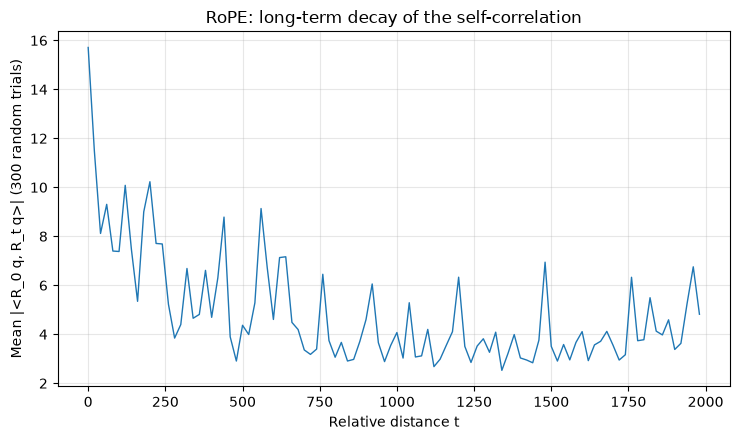

相対距離 0 での平均絶対内積: 15.7103
相対距離 1980 近傍(末尾 10 点)の平均絶対内積: 4.5793


In [18]:
torch.manual_seed(SEED)
N_TRIALS_A4 = 300
MAX_REL_DIST_A4 = 2000
rope_a4 = RotaryPositionEmbedding(D_K_A, max_position=MAX_REL_DIST_A4 + 1)
rel_distances_a4 = list(range(0, MAX_REL_DIST_A4, 20))

q_a4 = torch.randn(N_TRIALS_A4, 1, 1, D_K_A)
q_rot0_a4, _ = rope_a4.apply(q_a4, q_a4, positions=torch.tensor([0]))

mean_abs_dots_a4 = []
for rel_dist in rel_distances_a4:
    q_rot_t_a4, _ = rope_a4.apply(q_a4, q_a4, positions=torch.tensor([rel_dist]))
    dots_a4 = (q_rot0_a4 * q_rot_t_a4).sum(dim=-1).squeeze()
    mean_abs_dots_a4.append(dots_a4.abs().mean().item())

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.plot(rel_distances_a4, mean_abs_dots_a4, linewidth=1.0)
ax.set_xlabel("Relative distance t")
ax.set_ylabel("Mean |<R_0 q, R_t q>| (300 random trials)")
ax.set_title("RoPE: long-term decay of the self-correlation")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"相対距離 0 での平均絶対内積: {mean_abs_dots_a4[0]:.4f}")
window = 10  # 末尾付近の移動平均で振動をならして傾向を見る
tail_mean_a4 = sum(mean_abs_dots_a4[-window:]) / window
print(f"相対距離 {rel_distances_a4[-1]} 近傍(末尾 {window} 点)の平均絶対内積: {tail_mean_a4:.4f}")

#### 実験 A の結果・考察

- **A-1**: $R_{\Theta,m}^{\top} R_{\Theta,n}$ と $R_{\Theta,\,n-m}$ の最大要素誤差は $5.960 \times 10^{-8}$ であり、機械精度で一致した。3.8.5 節で証明したブロック対角性による関係が数値的にも成立している。
- **A-2**: 相対位置が同じ 4 組 $(m,n) \in \{(3,7), (10,14), (0,4), (50,54)\}$($n-m=4$ で共通)の内積はいずれも $-0.6933$ 付近に一致し(最大差 $1.192 \times 10^{-6}$)、3.8.1 節の要請(内積が相対位置のみに依存する)が実際に満たされていることを確認できた。
- **A-3a**: 明示的な行列積による実装(前半・後半ペア版、3.8.7 節)と`rotate_half`による効率的な実装の最大要素誤差は $2.384 \times 10^{-7}$ であり、機械精度で一致した。
- **A-3b**: 同一の $q, k$ に対し、前半・後半ペア版(3.8.7 節)の内積は $-0.6933$、隣接ペア版(3.8.4 節)の内積は $-1.3158$ であり、**一致しなかった**。次元ペアの取り方が異なれば、同一のベクトルに対する数値そのものは変わる。
- **A-3c**: 座標の固定置換 $P$ について、(1) $R^{\text{half}}_{\Theta,m} = P^{\top} R^{\text{interleaved}}_{\Theta,m} P$ の最大要素誤差は $0.000 \times 10^{0}$(完全に一致)であり、(2) $q, k$ に同じ置換 $P$ を適用すると隣接ペア版の内積は $-0.6933$ となり、A-3b の前半・後半ペア版の値($-0.6933$)と機械精度で一致することを確認した。この 2 つの取り方は座標の固定置換で厳密に移り合う関係にあり、この置換は $W^Q, W^K$ の再パラメータ化(列の並べ替え)に吸収されるため、**モデルの表現力としては等価** である(A-3b で見た「一致しない」という結果は、置換を揃えていない同一ベクトルを比較したことによるものであり、表現力の違いを意味しない)。これが 3.8.7 節で述べた「Query と Key に同一の置換を適用するため、相対位置のみへの依存という性質は保たれる」ことの数値的な裏付けになる。
- **A-4**: 相対距離 $t=0$ での平均絶対自己相関は $15.71$ であったのに対し、$t \approx 1980$〜$2000$ 近傍(末尾 10 点の平均)では $4.58$ まで減衰した。3.8.6 節で述べた通り、$d_k=16$・$\mathrm{base}=10000$ では最も低い周波数 $\theta_{7} \approx 3.16\times10^{-4}$ が 1 周するのに $2\pi/\theta_7 \approx 20000$ ステップを要するため、独立サンプルの Query・Key を数十〜数百程度の相対距離で平均しただけでは低周波成分がほとんど回転せず減衰が観測できない。相対距離のレンジを $0$〜$2000$ まで広げ、同一 Query の自己相関を見ることで、遠距離減衰の傾向を可視化できた。

### 6.2 実験 B: 位置エンコーディング方式の比較(学習を伴う)

**タスク設計についての注記**:`theories/README.md`の学習順序では 006「小型 GPT の事前学習」が本トピック(003)を前提としており、ここで言語モデリングを扱うと前提関係が逆転してしまう。そのため、位置情報が本質的に効く合成タスクとして **可変長 copy task** を用いる。

**タスク**: 系列 $[x_1, \dots, x_L, \mathrm{SEP}, x_1, \dots, x_L]$ を構成し、因果マスクを用いた Decoder のみの構成(EncoderBlock を因果マスクで使うことで、cross-attention を持たない GPT スタイルの decoder-only 構成になる、002・実験 1 と同じ手法)で後半部分(2 回目の $x_1, \dots, x_L$)を予測する。損失・精度は後半部分のみについて計算する。系列長 $L$ を学習の各ステップでランダムに変えることで、モデルが特定の絶対長ではなく「相対的な参照パターン」を学習するように促す。

**語彙サイズについての設計判断**: 語彙サイズを大きく取ると、先頭から連続する部分列の中で重複がほとんど発生しないため、「直前に出た同じトークンを探し、その次のトークンをコピーする」という **内容に基づく induction 機構**(位置情報がなくても学習できる)だけでタスクがある程度解けてしまい、位置エンコーディング方式間の差が出にくい。そこで語彙サイズを $6$ と小さく設定し、系列内で同じトークンが複数回出現するようにした。これにより「直前の同一トークンの次を見る」だけでは参照先が曖昧になり、位置情報(絶対位置または相対位置)に基づく参照が本質的に必要になる。

In [19]:
CONTENT_VOCAB_SIZE = 6  # 小さい語彙サイズで内容ベース induction のみでの解決を妨げる(上記参照)
SEP_TOKEN_ID = CONTENT_VOCAB_SIZE
VOCAB_SIZE_B = CONTENT_VOCAB_SIZE + 1

D_MODEL_B, N_HEADS_B, D_FF_B, N_LAYERS_B = 64, 4, 256, 2
L_MIN_TRAIN, L_MAX_TRAIN = 4, 16  # 学習時の系列長 L の範囲
EXTRAPOLATION_RATIOS = [1.5, 2.0, 3.0, 4.0]
EXTRAPOLATION_LENGTHS = [int(L_MAX_TRAIN * r) for r in EXTRAPOLATION_RATIOS]
MAX_EVAL_LEN_B = 2 * max(EXTRAPOLATION_LENGTHS) + 1  # cos/sin キャッシュなどのバッファ用

TRAIN_STEPS_B = 2500
BATCH_SIZE_B = 64
LR_B = 3e-4
SEEDS_B = [0, 1, 2]  # 条件間の差を seed 間のばらつきと区別するため、複数 seed で学習する

T5_NUM_BUCKETS = 32
T5_MAX_DISTANCE = 64

print(f"学習時の L の範囲: [{L_MIN_TRAIN}, {L_MAX_TRAIN}]")
print(f"外挿評価の L: {EXTRAPOLATION_LENGTHS} (学習長 {L_MAX_TRAIN} の {EXTRAPOLATION_RATIOS} 倍)")
print(f"学習・評価に用いる seed: {SEEDS_B}")

学習時の L の範囲: [4, 16]
外挿評価の L: [24, 32, 48, 64] (学習長 16 の [1.5, 2.0, 3.0, 4.0] 倍)
学習・評価に用いる seed: [0, 1, 2]


In [20]:
def make_copy_batch(
    batch_size: int, seq_len_l: int, device: str
) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    """可変長 copy task のバッチを生成する。

    系列は [x_1, ..., x_L, SEP, x_1, ..., x_L] の形で、次のトークン予測用に
    (入力, 目標, 損失を計算する位置のマスク)を返す。損失マスクは後半部分
    (2 回目に現れる x_1, ..., x_L を予測する位置)のみ True になる。
    """
    first_half = torch.randint(0, CONTENT_VOCAB_SIZE, (batch_size, seq_len_l), device=device)
    sep = torch.full((batch_size, 1), SEP_TOKEN_ID, device=device)
    full_sequence = torch.cat([first_half, sep, first_half], dim=1)  # (B, 2L+1)

    input_ids = full_sequence[:, :-1]
    target_ids = full_sequence[:, 1:]
    total_len = input_ids.size(1)
    # 入力位置 t(0-indexed)の目標が後半部分の予測に対応するのは t >= L のとき
    loss_mask = torch.arange(total_len, device=device) >= seq_len_l
    return input_ids, target_ids, loss_mask


# 動作確認
_ids, _tgt, _mask = make_copy_batch(2, 4, "cpu")
print("input :", _ids[0].tolist())
print("target:", _tgt[0].tolist())
print("mask  :", _mask.tolist())

input : [0, 5, 3, 0, 6, 0, 5, 3]
target: [5, 3, 0, 6, 0, 5, 3, 0]
mask  : [False, False, False, False, True, True, True, True]


**モデル**: 002 で実装した`EncoderBlock`(因果マスク付き、正規化前置)を 2 層積んだものを使う。埋め込みへの加算方式(正弦波・学習可能な絶対位置埋め込み)は埋め込み層に、RoPE・Shaw et al. 方式・T5・ALiBi は各層の`self_attn`を対応する`positional_transform`/`attention_score_bias`を指定した`MultiHeadAttention`に差し替えることで組み込む。`EncoderBlock`自体は変更しない。

In [21]:
class PositionalEncodingCopyModel(nn.Module):
    """可変長 copy task 用のモデル(比較する 7 条件を 1 つのクラスで表現する)。

    embedding_mode: 埋め込みへの加算方式("none" / "sinusoidal" / "learned")。
    positional_transform_factory: 各層の self_attn に渡す QueryKeyPositionalTransform
        のファクトリ(例: RoPE)。None なら使わない。
    score_bias_factory: 各層の self_attn に渡す AttentionScoreBias のファクトリ
        (例: Shaw et al. 方式・T5・ALiBi)。None なら使わない。
    """

    def __init__(
        self,
        embedding_mode: str,
        positional_transform_factory=None,
        score_bias_factory=None,
        max_learned_len: int = 2 * L_MAX_TRAIN + 1,
    ) -> None:
        super().__init__()
        self.token_embedding = nn.Embedding(VOCAB_SIZE_B, D_MODEL_B)

        self.pos_embedding: nn.Module | None
        if embedding_mode == "sinusoidal":
            self.pos_embedding = SinusoidalPositionalEncoding(D_MODEL_B, max_len=MAX_EVAL_LEN_B)
        elif embedding_mode == "learned":
            # 学習時の最大系列長ちょうどに max_len を設定する(3.4 節: 外挿できないことを
            # 明示的に示すため、学習長を超える位置を要求すると ValueError が送出される)。
            self.pos_embedding = LearnedAbsolutePositionalEmbedding(
                D_MODEL_B, max_len=max_learned_len
            )
        else:
            self.pos_embedding = None

        self.blocks = nn.ModuleList()
        for _ in range(N_LAYERS_B):
            block = EncoderBlock(D_MODEL_B, N_HEADS_B, D_FF_B, norm_first=True)
            if positional_transform_factory is not None or score_bias_factory is not None:
                block.self_attn = MultiHeadAttention(
                    D_MODEL_B,
                    N_HEADS_B,
                    positional_transform=(
                        positional_transform_factory() if positional_transform_factory else None
                    ),
                    attention_score_bias=(score_bias_factory() if score_bias_factory else None),
                )
            self.blocks.append(block)

        self.output_proj = nn.Linear(D_MODEL_B, VOCAB_SIZE_B)

    def forward(self, input_ids: torch.Tensor) -> tuple[torch.Tensor, list[torch.Tensor]]:
        """順伝播。

        Returns:
            (logits, attn_weights_per_layer) のタプル。attn_weights_per_layer は
            層ごとの Attention 重み(形状 (B, h, S, S))のリストで、リストの長さは
            self.blocks の層数。最終層だけでなく全層を観測できるようにするため、
            上書きせずリストに積む(6.3 節: copy 機構がどの層・どのヘッドに
            載るかを層をまたいで調べるために必要)。
        """
        h = self.token_embedding(input_ids)
        if self.pos_embedding is not None:
            h = self.pos_embedding(h)
        seq_len = input_ids.size(1)
        mask = create_causal_mask(seq_len, device=input_ids.device)
        attn_weights_per_layer = []
        for block in self.blocks:
            h, attn_weights = block(h, mask)
            attn_weights_per_layer.append(attn_weights)
        logits = self.output_proj(h)
        return logits, attn_weights_per_layer


D_K_B = D_MODEL_B // N_HEADS_B

MODEL_FACTORIES = {
    "none": lambda: PositionalEncodingCopyModel("none"),
    "sinusoidal": lambda: PositionalEncodingCopyModel("sinusoidal"),
    "learned": lambda: PositionalEncodingCopyModel("learned"),
    "shaw": lambda: PositionalEncodingCopyModel(
        "none",
        score_bias_factory=lambda: ShawRelativePositionBias(
            D_K_B, max_relative_position=L_MAX_TRAIN
        ),
    ),
    "t5": lambda: PositionalEncodingCopyModel(
        "none",
        score_bias_factory=lambda: T5RelativePositionBias(
            N_HEADS_B, num_buckets=T5_NUM_BUCKETS, max_distance=T5_MAX_DISTANCE, bidirectional=False
        ),
    ),
    "alibi": lambda: PositionalEncodingCopyModel(
        "none", score_bias_factory=lambda: ALiBiPositionBias(N_HEADS_B)
    ),
    "rope": lambda: PositionalEncodingCopyModel(
        "none",
        positional_transform_factory=lambda: RotaryPositionEmbedding(
            D_K_B, max_position=MAX_EVAL_LEN_B
        ),
    ),
}
CONDITION_LABELS = {
    "none": "None (baseline)",
    "sinusoidal": "Sinusoidal",
    "learned": "Learned Absolute",
    "shaw": "Shaw et al.",
    "t5": "T5 relative bias",
    "alibi": "ALiBi",
    "rope": "RoPE",
}
print(f"比較する条件: {list(MODEL_FACTORIES.keys())}")

比較する条件: ['none', 'sinusoidal', 'learned', 'shaw', 't5', 'alibi', 'rope']


In [22]:
def evaluate_copy_task(
    model: nn.Module, seq_len_l: int, n_batches: int = 4, batch_size: int = 64, device: str = "cpu"
) -> tuple[float, float]:
    """指定した L で評価し、(平均損失, 精度) を返す。max_len を超える場合は (nan, nan)。"""
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for _ in range(n_batches):
            input_ids, target_ids, loss_mask = make_copy_batch(batch_size, seq_len_l, device)
            try:
                logits, _ = model(input_ids)
            except ValueError:
                return float("nan"), float("nan")
            log_probs = torch.log_softmax(logits, dim=-1)
            masked_log_probs = log_probs[:, loss_mask].reshape(-1, VOCAB_SIZE_B)
            masked_targets = target_ids[:, loss_mask].reshape(-1)
            loss = nn.functional.nll_loss(masked_log_probs, masked_targets)
            total_loss += loss.item()
            pred = logits[:, loss_mask].argmax(dim=-1)
            correct += (pred == target_ids[:, loss_mask]).sum().item()
            total += pred.numel()
    return total_loss / n_batches, correct / total


def train_copy_model(name: str, seed: int = SEEDS_B[0]) -> tuple[nn.Module, float]:
    """copy task で 1 条件を学習し、(モデル, 学習時間[秒]) を返す。"""
    torch.manual_seed(seed)
    model = MODEL_FACTORIES[name]().to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR_B)

    start = time.time()
    for _ in range(TRAIN_STEPS_B):
        seq_len_l = torch.randint(L_MIN_TRAIN, L_MAX_TRAIN + 1, (1,)).item()
        input_ids, target_ids, loss_mask = make_copy_batch(BATCH_SIZE_B, seq_len_l, DEVICE)
        logits, _ = model(input_ids)
        log_probs = torch.log_softmax(logits, dim=-1)
        loss = nn.functional.nll_loss(
            log_probs[:, loss_mask].reshape(-1, VOCAB_SIZE_B), target_ids[:, loss_mask].reshape(-1)
        )
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    elapsed = time.time() - start
    return model, elapsed

In [23]:
def _nan_safe_stat(arr: np.ndarray, func) -> list[float]:
    """列(系列長)ごとに集計する。全 seed が nan の列(学習可能な絶対位置埋め込みが
    max_len を超えて評価不能になった場合)は nan をそのまま返し、`np.nanmean`
    などを全 nan 列に対して呼んで出る RuntimeWarning を避ける。
    """
    result = []
    for col in arr.T:
        if np.all(np.isnan(col)):
            result.append(float("nan"))
        else:
            result.append(float(func(col)))
    return result


results_exp_b = {}
trained_models_b = {}
eval_lengths_b = [L_MAX_TRAIN] + EXTRAPOLATION_LENGTHS

for name in MODEL_FACTORIES:
    per_seed_losses, per_seed_accs, per_seed_times = [], [], []
    trained_models_b[name] = {}

    for seed in SEEDS_B:
        model_b, elapsed_b = train_copy_model(name, seed=seed)
        trained_models_b[name][seed] = model_b
        per_seed_times.append(elapsed_b)

        losses_b, accs_b = [], []
        for l_eval in eval_lengths_b:
            loss_b, acc_b = evaluate_copy_task(model_b, l_eval, device=DEVICE)
            losses_b.append(loss_b)
            accs_b.append(acc_b)
        per_seed_losses.append(losses_b)
        per_seed_accs.append(accs_b)

    losses_arr = np.array(per_seed_losses)  # (len(SEEDS_B), len(eval_lengths_b))
    accs_arr = np.array(per_seed_accs)

    results_exp_b[name] = {
        "lengths": eval_lengths_b,
        "losses_mean": _nan_safe_stat(losses_arr, np.nanmean),
        "losses_min": _nan_safe_stat(losses_arr, np.nanmin),
        "losses_max": _nan_safe_stat(losses_arr, np.nanmax),
        "accs_mean": _nan_safe_stat(accs_arr, np.nanmean),
        "accs_min": _nan_safe_stat(accs_arr, np.nanmin),
        "accs_max": _nan_safe_stat(accs_arr, np.nanmax),
        "time_mean": sum(per_seed_times) / len(per_seed_times),
        "per_seed_accs": per_seed_accs,
    }

    print(
        f"{CONDITION_LABELS[name]:20s} time={results_exp_b[name]['time_mean']:5.1f}s(seed 平均)  "
        + "  ".join(
            f"L={l_eval}:acc={mean:.3f}[{lo:.3f},{hi:.3f}]"
            for l_eval, mean, lo, hi in zip(
                eval_lengths_b,
                results_exp_b[name]["accs_mean"],
                results_exp_b[name]["accs_min"],
                results_exp_b[name]["accs_max"],
                strict=True,
            )
        )
    )

None (baseline)      time= 22.3s(seed 平均)  L=16:acc=0.634[0.587,0.668]  L=24:acc=0.478[0.448,0.501]  L=32:acc=0.390[0.352,0.424]  L=48:acc=0.308[0.284,0.342]  L=64:acc=0.266[0.246,0.298]


Sinusoidal           time= 22.3s(seed 平均)  L=16:acc=0.986[0.982,0.991]  L=24:acc=0.221[0.187,0.248]  L=32:acc=0.238[0.214,0.269]  L=48:acc=0.242[0.230,0.254]  L=64:acc=0.213[0.203,0.225]


Learned Absolute     time= 23.0s(seed 平均)  L=16:acc=0.813[0.787,0.848]  L=24:acc=nan[nan,nan]  L=32:acc=nan[nan,nan]  L=48:acc=nan[nan,nan]  L=64:acc=nan[nan,nan]


Shaw et al.          time= 24.0s(seed 平均)  L=16:acc=0.959[0.929,0.975]  L=24:acc=0.891[0.798,0.947]  L=32:acc=0.813[0.674,0.904]  L=48:acc=0.642[0.489,0.756]  L=64:acc=0.505[0.392,0.595]


T5 relative bias     time= 23.0s(seed 平均)  L=16:acc=0.725[0.576,0.862]  L=24:acc=0.376[0.344,0.424]  L=32:acc=0.451[0.269,0.631]  L=48:acc=0.275[0.258,0.286]  L=64:acc=0.277[0.229,0.323]


ALiBi                time= 21.4s(seed 平均)  L=16:acc=0.967[0.964,0.969]  L=24:acc=0.920[0.913,0.925]  L=32:acc=0.855[0.849,0.863]  L=48:acc=0.711[0.692,0.722]  L=64:acc=0.603[0.578,0.615]


RoPE                 time= 22.8s(seed 平均)  L=16:acc=0.988[0.983,0.992]  L=24:acc=0.330[0.280,0.367]  L=32:acc=0.311[0.299,0.329]  L=48:acc=0.173[0.168,0.177]  L=64:acc=0.167[0.163,0.175]


#### 実験 B-1: 学習長内での性能

学習時と同じ範囲(ここでは $L = L_{\max} = 16$)での精度を比較する。ここで測っているのは **位置情報の表現力そのもの** である(学習長を超えないため、外挿性能は問わない)。

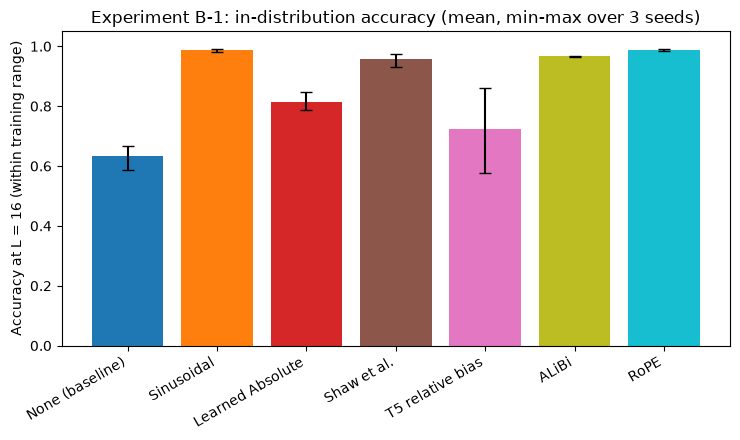

None (baseline)      L=16: loss=0.9653  acc(mean)=0.6340  acc(min-max)=[0.5869, 0.6677]
Sinusoidal           L=16: loss=0.0356  acc(mean)=0.9863  acc(min-max)=[0.9822, 0.9907]
Learned Absolute     L=16: loss=0.4737  acc(mean)=0.8129  acc(min-max)=[0.7874, 0.8477]
Shaw et al.          L=16: loss=0.1126  acc(mean)=0.9591  acc(min-max)=[0.9292, 0.9753]
T5 relative bias     L=16: loss=0.7192  acc(mean)=0.7253  acc(min-max)=[0.5757, 0.8616]
ALiBi                L=16: loss=0.0940  acc(mean)=0.9666  acc(min-max)=[0.9639, 0.9692]
RoPE                 L=16: loss=0.0348  acc(mean)=0.9878  acc(min-max)=[0.9829, 0.9917]


In [24]:
fig, ax = plt.subplots(figsize=(7.5, 4.5))
names_b1 = list(MODEL_FACTORIES.keys())
means_b1 = np.array(
    [results_exp_b[name]["accs_mean"][0] for name in names_b1]
)  # 先頭が L_MAX_TRAIN
mins_b1 = np.array([results_exp_b[name]["accs_min"][0] for name in names_b1])
maxs_b1 = np.array([results_exp_b[name]["accs_max"][0] for name in names_b1])
yerr_b1 = np.vstack([means_b1 - mins_b1, maxs_b1 - means_b1])

colors_b1 = plt.cm.tab10(np.linspace(0, 1, len(names_b1)))
ax.bar(
    [CONDITION_LABELS[n] for n in names_b1],
    means_b1,
    yerr=yerr_b1,
    capsize=4,
    color=colors_b1,
)
ax.set_ylabel(f"Accuracy at L = {L_MAX_TRAIN} (within training range)")
ax.set_title(f"Experiment B-1: in-distribution accuracy (mean, min-max over {len(SEEDS_B)} seeds)")
ax.set_ylim(0, 1.05)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

for name in names_b1:
    r = results_exp_b[name]
    print(
        f"{CONDITION_LABELS[name]:20s} L={L_MAX_TRAIN}: "
        f"loss={r['losses_mean'][0]:.4f}  "
        f"acc(mean)={r['accs_mean'][0]:.4f}  "
        f"acc(min-max)=[{r['accs_min'][0]:.4f}, {r['accs_max'][0]:.4f}]"
    )

#### 実験 B-2: 学習長を超える外挿性能

学習時の最大系列長($L_{\max}=16$)の 1.5, 2, 3, 4 倍の複数の長さで評価する。ここで測っているのは **外挿(length extrapolation)性能** である。

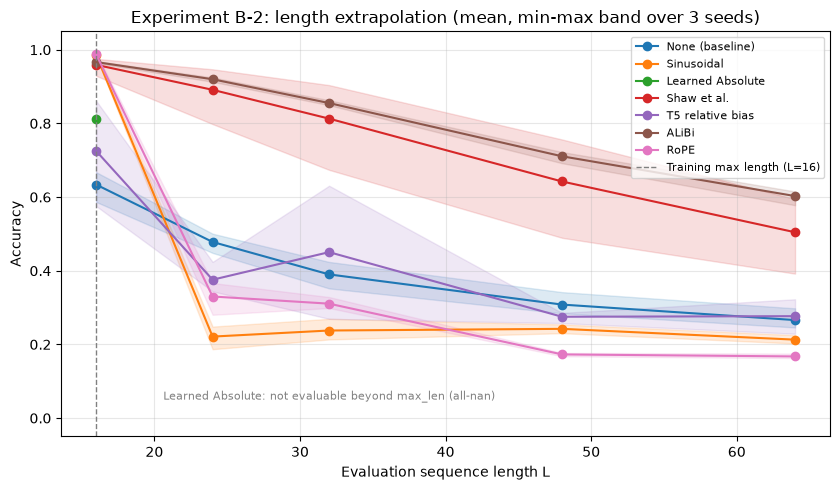

In [25]:
fig, ax = plt.subplots(figsize=(8.5, 5.0))
for name in MODEL_FACTORIES:
    r = results_exp_b[name]
    lengths_b2 = r["lengths"]
    means_b2 = r["accs_mean"]
    mins_b2 = r["accs_min"]
    maxs_b2 = r["accs_max"]
    (line,) = ax.plot(lengths_b2, means_b2, marker="o", label=CONDITION_LABELS[name])
    ax.fill_between(lengths_b2, mins_b2, maxs_b2, color=line.get_color(), alpha=0.15)

ax.axvline(
    L_MAX_TRAIN,
    color="gray",
    linestyle="--",
    linewidth=1,
    label=f"Training max length (L={L_MAX_TRAIN})",
)
ax.text(
    EXTRAPOLATION_LENGTHS[1],
    0.05,
    "Learned Absolute: not evaluable beyond max_len (all-nan)",
    fontsize=8,
    color="gray",
    ha="center",
)
ax.set_xlabel("Evaluation sequence length L")
ax.set_ylabel("Accuracy")
ax.set_title(f"Experiment B-2: length extrapolation (mean, min-max band over {len(SEEDS_B)} seeds)")
ax.set_ylim(-0.05, 1.05)
ax.legend(loc="upper right", fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**T5 の相対距離バケットの補足分析**: T5(`num_buckets=32`・`max_distance=64`・`bidirectional=False`)が学習中に実際に受け取る相対距離の範囲と、評価時に受け取る範囲を比較する。学習時の入力系列長は最大でも $2 L_{\max} = 32$ であり、causal な自己注意で意味を持つ相対距離(Key が Query 以前にある場合)は高々 $31$ である。

In [26]:
t5_probe = T5RelativePositionBias(
    N_HEADS_B, num_buckets=T5_NUM_BUCKETS, max_distance=T5_MAX_DISTANCE, bidirectional=False
)

max_rel_dist_train = 2 * L_MAX_TRAIN - 1  # 学習中に現れる最大の相対距離(n - m の絶対値)
train_rel_distances = torch.arange(0, max_rel_dist_train + 1)
train_buckets = t5_probe.relative_position_bucket(-train_rel_distances)
max_trained_bucket = train_buckets.max().item()

all_buckets = torch.arange(T5_NUM_BUCKETS)
untrained_buckets = (all_buckets > max_trained_bucket).sum().item()

eval_rel_dist_l64 = 2 * EXTRAPOLATION_LENGTHS[-1] - 1  # L=64 での最大相対距離
eval_bucket_l64 = t5_probe.relative_position_bucket(torch.tensor([-eval_rel_dist_l64])).item()

print(f"学習中に現れる最大相対距離: {max_rel_dist_train} -> バケット {max_trained_bucket}")
print(f"学習中に一度も勾配を受けないバケット数: {untrained_buckets} / {T5_NUM_BUCKETS}")
eval_l64 = EXTRAPOLATION_LENGTHS[-1]
print(f"評価 L={eval_l64} での最大相対距離: {eval_rel_dist_l64} -> バケット {eval_bucket_l64}")

学習中に現れる最大相対距離: 31 -> バケット 23
学習中に一度も勾配を受けないバケット数: 8 / 32
評価 L=64 での最大相対距離: 127 -> バケット 31


#### 実験 B の結果・考察

実測値(6.2 節の実行結果より、$3$ seed(0, 1, 2)の平均値、括弧内は最小値・最大値)は以下の通り。

**実験 B-1(学習長内 $L=16$、3.2〜3.8 節との対応)**:

| 条件 | 損失(平均) | 精度(平均 [最小, 最大]) |
|---|---:|---|
| なし(対照群) | 0.9653 | 0.6340 [0.5869, 0.6677] |
| 正弦波方式 | 0.0356 | 0.9863 [0.9822, 0.9907] |
| 学習可能な絶対位置埋め込み | 0.4737 | 0.8129 [0.7874, 0.8477] |
| Shaw et al. 方式 | 0.1126 | 0.9591 [0.9292, 0.9753] |
| T5 の相対位置バイアス | 0.7192 | 0.7253 [0.5757, 0.8616] |
| ALiBi | 0.0940 | 0.9666 [0.9639, 0.9692] |
| RoPE | 0.0348 | 0.9878 [0.9829, 0.9917] |

3 seed の最小・最大の範囲を比較すると、条件間には次のようなまとまりが見える。

- **RoPE(0.988)・正弦波方式(0.986)** は、最小値(それぞれ 0.983・0.982)が ALiBi・Shaw et al. 方式の最大値(それぞれ 0.969・0.975)を上回っており、この 2 条件は他の条件よりはっきり高い精度に達したと言える。
- **ALiBi(0.967)・Shaw et al. 方式(0.959)** は範囲が重なっており(ALiBi の範囲 $[0.964, 0.969]$ は Shaw et al. 方式の範囲 $[0.929, 0.975]$ に完全に含まれる)、この 2 条件の間の差は $3$ seed では区別できない。
- **学習可能な絶対位置埋め込み(0.813)** は ALiBi・Shaw et al. 方式より明確に低い(最大値 0.848 が Shaw et al. 方式の最小値 0.929 を下回る)。
- **T5(0.725)・対照群(0.634)** は範囲が重なっており(対照群の範囲 $[0.587, 0.668]$ は T5 の範囲 $[0.576, 0.862]$ に含まれる)、両者の間の差は $3$ seed では区別できない。ただし T5 の分散は非常に大きく(範囲 $0.29$)、seed によって対照群並みの精度から学習可能な絶対位置埋め込みに匹敵する精度まで大きくばらついた。

**対照群(位置エンコーディングなし)がチャンスレベルを大きく上回る理由**: 語彙サイズ $6$ に対するチャンスレベルの精度は約 $1/6 \approx 0.167$ であるのに対し、対照群は $0.634$ に達している。これは 3.1 節で述べた通り、本タスクが因果マスク付き decoder-only 構成を用いているためである。因果マスクの下では位置 $m$ の Query が参照できる Key の集合が $\{0, \dots, m\}$ に制限され、この非対称性自体が暗黙の位置情報として働く。加えて、「直前に出た同一トークンの次を見る」という内容ベースの induction 機構(位置エンコーディングを必要としない)も一定の精度に寄与しうる。6.2 節冒頭で述べた通り、語彙サイズを $6$ と小さくしたことで induction 機構単独ではタスクを解けないようにしているが、部分的な寄与までは排除できていない。Haviv et al. [7] が報告する「位置エンコーディングを持たない因果的言語モデルも位置情報を獲得する」という知見と整合する結果である。

**実験 B-2(学習長超、3.4・3.7・3.8 節との対応)**:

| 条件 | L=24 | L=32 | L=48 | L=64($4\times$) |
|---|---|---|---|---|
| なし | 0.478 [0.448, 0.501] | 0.390 [0.352, 0.424] | 0.308 [0.284, 0.342] | 0.266 [0.246, 0.298] |
| 正弦波方式 | 0.221 [0.187, 0.248] | 0.238 [0.214, 0.269] | 0.242 [0.230, 0.254] | 0.213 [0.203, 0.225] |
| 学習可能な絶対位置埋め込み | nan | nan | nan | nan |
| Shaw et al. 方式 | 0.891 [0.798, 0.947] | 0.813 [0.674, 0.904] | 0.642 [0.489, 0.756] | 0.505 [0.392, 0.595] |
| T5 | 0.376 [0.344, 0.424] | 0.451 [0.269, 0.631] | 0.275 [0.258, 0.286] | 0.277 [0.229, 0.323] |
| ALiBi | 0.920 [0.913, 0.925] | 0.855 [0.849, 0.863] | 0.711 [0.692, 0.722] | 0.603 [0.578, 0.615] |
| RoPE | 0.330 [0.280, 0.367] | 0.311 [0.299, 0.329] | 0.173 [0.168, 0.177] | 0.167 [0.163, 0.175] |

学習可能な絶対位置埋め込みは、3.4 節で述べた通り学習時の`max_len`($=2L_{\max}+1=33$)を超える位置を要求すると`ValueError`が送出され、評価結果が全域で`nan`になった。これは「性能が劣化する」のではなく「原理的にそもそも動作しない」という、3.4 節の議論をそのまま裏付ける結果である。

実験前の想定では「RoPE・正弦波方式は $L=48$・$L=64$ あたりで対照群を下回る」という緩やかな劣化を見込んでいたが、$3$ seed の実測値はこれよりも厳しい結果を示した。**正弦波方式・RoPE はいずれも、$1.5$ 倍長($L=24$)の時点ですでに対照群を下回り、比較した $4$ つの外挿長すべてで対照群を下回り続けた**。いずれの外挿長でも $3$ seed の最小・最大の範囲に重なりはない($L=24$: 正弦波方式 $0.221$ / RoPE $0.330$ に対し対照群 $0.478$、$L=32$: $0.238$ / $0.311$ に対し $0.390$、$L=48$: $0.242$ / $0.173$ に対し $0.308$、$L=64$: $0.213$ / $0.167$ に対し $0.266$)。T5 も $L=24$ では対照群を下回り(T5 $0.376$ に対し対照群 $0.478$、重なりなし)、$L=32$〜$L=64$ では対照群との範囲が重なり区別できない水準まで落ち込んだ。

この結果は、3.1 節で追加した議論と接続すると解釈しやすい。因果マスクだけが与える暗黙の位置情報(対照群が使っている情報)は、系列長によらず一貫した性質(「位置 $m$ は $m+1$ 個の Key しか参照できない」)であり、学習長を超えても意味を失わない。一方、正弦波方式・RoPE・T5 が学習時に学習した位置パターンは学習長の範囲でのみ意味を持つよう最適化されており、学習長を超えた位置に対しては **学習時に見たことのない、意味をなさない信号** を Attention に持ち込むことになる。この意味をなさない信号が、因果マスク由来の暗黙の位置情報だけに頼るよりも有害に働きうる、というのが今回の結果である。

対照的に、**ALiBi(0.603 @ $L=64$)・Shaw et al. 方式(0.505 @ $L=64$)は、比較した $7$ 条件の中で最も緩やかな劣化を示し、全外挿長で対照群を明確に上回り続けた**。ただし ALiBi と Shaw et al. 方式の範囲は各長さで重なっており(例えば $L=64$: ALiBi $[0.578, 0.615]$ に対し Shaw et al. 方式 $[0.392, 0.595]$)、$3$ seed では両者の優劣を確定的には言えない。ALiBi は Shaw et al. 方式より分散が小さく安定して高い精度を維持した点が目立つが、Shaw et al. 方式も $k_{\text{clip}}=16$ による相対距離のクリップ(3.5 節)のおかげで、クリップ範囲を超えた遠距離では新しい情報が増えないため、対照群を上回る精度を保った。

これは、3.7 節で述べた通り **ALiBi が外挿を明示的な設計目標としている手法である**([5] のタイトル "Train Short, Test Long" の通り)ことの帰結であり、RoPE が素の状態では学習長を大きく超えると性能が急激に劣化しやすいという既知の傾向と整合する。**これは「ALiBi の方が優れた手法である」ことを意味しない** — 学習長内の表現力(実験 B-1)では RoPE・正弦波方式が ALiBi を上回っており、測っている軸が異なるためである(7 節でこの点を統合的に考察する)。

**T5 の挙動について**: 5.3 節の`T5RelativePositionBias`(`num_buckets=32`・`max_distance=64`・`bidirectional=False`)を用いた補足分析(6.2 節末尾)によると、学習中に現れる最大の相対距離は $31$ であり、これはバケット $23$ に対応する。すなわち、バケット $24$〜$31$(全 $32$ バケット中 $8$ 個、$25\%$)は **学習中に一度も勾配を受けていない**。評価時 $L=64$ では相対距離が最大 $127$ に達し、バケット $31$(学習中に一度も学習されていないオーバーフローバケット)に落ちる。$L=24$(相対距離最大 $47$)の時点ですでに相対距離 $32$ 以上でバケット $24$ 以降(未学習領域)に入る。これが、T5 が RoPE・正弦波方式と同様に外挿性能が低い(むしろ $L=24$ では対照群も下回る)ことの具体的な要因だと考えられる。

### 6.3 実験 C: Attention 重みの可視化

正弦波方式・ALiBi・RoPE(および対照群)について、copy task が実際に「参照すべき位置に注目できているか」を定量指標で確認したうえで、代表例をヒートマップで可視化する。学習長内($L=16$)と学習長を超える系列($L=32$、学習長の 2 倍)の両方で評価し、外挿時に何が壊れるのかを確認する。モデルは 2 層(`N_LAYERS_B`)・ヘッド数 $4$(`N_HEADS_B`)であり、指標は特定の層・ヘッドに決め打ちせず **全層・全ヘッド** を対象に計算する(理由は後述)。

**参照すべき位置のオフセットについて**:`make_copy_batch`(6.2 節)が構成する系列は`[x_1, ..., x_L, SEP, x_1, ..., x_L]`であり、`input_ids`はこの系列の末尾 1 トークンを除いたもの(長さ $2L$、0-indexed で位置 $0$〜$2L-1$)である。位置 $L$ が`SEP`、位置 $L+1+j$($j=0,\dots,L-1$)が 2 回目の $x_{j+1}$ に対応する。後半の位置 $m$($m \ge L$)の次のトークンを予測するための正解は`target_ids[m] = full_sequence[m+1]`であり、$m=L+j$ のとき`full_sequence[L+j+1] = x_{j+1} = \text{full\_sequence}[j]`(前半の位置 $j = m - L$ の値)と一致する。したがって、位置 $m$ が参照すべき前半の位置は $m - L$ である(以下の指標計算はこの値を用いる)。

In [27]:
def compute_chance_level(seq_len_l: int, device: str = "cpu") -> float:
    """因果マスク下で一様な Attention 重みを仮定した場合のチャンスレベルを計算する。

    位置 m(m = L, ..., 2L-1)は m+1 個の Key(位置 0..m)に一様に注意を割り振ると
    仮定すると、参照位置 m-L への重みの期待値は 1/(m+1) である。指標は後半の
    全位置で平均するため、チャンスレベルは (1/L) * sum_{m=L}^{2L-1} 1/(m+1)。
    argmax が参照位置と一致する確率も、一様分布上ではどの位置も等確率で
    argmax になりうるとみなせるため、同じ 1/(m+1) の平均に一致する。
    """
    m_positions = torch.arange(seq_len_l, 2 * seq_len_l, device=device)
    return (1.0 / (m_positions + 1).float()).mean().item()


def compute_attention_concentration_all_heads(
    model: nn.Module, seq_len_l: int, device: str = "cpu", n_samples: int = 8
) -> tuple[torch.Tensor, torch.Tensor]:
    """全層・全ヘッドについて、参照位置への重みと argmax 一致率を計算する。

    Returns:
        (weight_at_ref, argmax_match) のタプル。いずれも形状 (n_layers, h) の
        Tensor(n_samples 個のバッチ・後半全位置で平均した値)。
    """
    model.eval()
    weight_sum: torch.Tensor | None = None
    match_sum: torch.Tensor | None = None
    with torch.no_grad():
        for _ in range(n_samples):
            input_ids, _, _ = make_copy_batch(1, seq_len_l, device)
            _, attn_weights_per_layer = model(input_ids)
            m_positions = torch.arange(seq_len_l, 2 * seq_len_l, device=device)
            ref_positions = m_positions - seq_len_l

            layer_weights, layer_matches = [], []
            for attn_weights in attn_weights_per_layer:
                attn = attn_weights[0]  # (h, S, S)
                w = attn[:, m_positions, ref_positions]  # (h, len(m_positions))
                layer_weights.append(w.mean(dim=-1))  # (h,)
                argmax_pred = attn[:, m_positions, :].argmax(dim=-1)  # (h, len(m_positions))
                match = (argmax_pred == ref_positions[None, :]).float().mean(dim=-1)  # (h,)
                layer_matches.append(match)

            layer_weights_t = torch.stack(layer_weights)  # (n_layers, h)
            layer_matches_t = torch.stack(layer_matches)
            if weight_sum is None:
                weight_sum, match_sum = layer_weights_t, layer_matches_t
            else:
                weight_sum = weight_sum + layer_weights_t
                match_sum = match_sum + layer_matches_t
    return weight_sum / n_samples, match_sum / n_samples


METRIC_CONDITIONS_C = ["none", "sinusoidal", "alibi", "rope"]
concentration_full = {}

for name in METRIC_CONDITIONS_C:
    for l_vis in (L_MAX_TRAIN, 2 * L_MAX_TRAIN):
        weight_per_seed, match_per_seed = [], []
        best_layer_per_seed, best_head_per_seed = [], []
        for seed in SEEDS_B:
            torch.manual_seed(seed)
            w, m = compute_attention_concentration_all_heads(
                trained_models_b[name][seed], l_vis, DEVICE
            )
            weight_per_seed.append(w)
            match_per_seed.append(m)
            best_layer, best_head = divmod(w.argmax().item(), w.size(1))
            best_layer_per_seed.append(best_layer)
            best_head_per_seed.append(best_head)
        concentration_full[(name, l_vis)] = {
            "weight_per_seed": weight_per_seed,  # 各 seed: (n_layers, h)
            "match_per_seed": match_per_seed,
            "best_layer_per_seed": best_layer_per_seed,  # 各 seed: 重み最大の層
            "best_head_per_seed": best_head_per_seed,  # 各 seed: 重み最大のヘッド
        }

# 表 1(主表): 条件 x 系列長ごとに、重み(weight_at_ref)が最大となる (層, ヘッド) を
# seed ごとに求め、その (層, ヘッド) における重みと argmax 一致率の両方を集計する。
# 2 つの指標を別々に最大化すると異なる (層, ヘッド) 由来の値が並びうるため、
# 同一の (層, ヘッド) の値を揃えて表にする。
print("=== 表 1: 重みが最大の (層, ヘッド) における重み・argmax 一致率(seed 平均[最小,最大]) ===")
table1_rows = {}
for name in METRIC_CONDITIONS_C:
    for l_vis in (L_MAX_TRAIN, 2 * L_MAX_TRAIN):
        r = concentration_full[(name, l_vis)]
        weight_at_best_per_seed = []
        match_at_best_per_seed = []
        for seed_idx in range(len(SEEDS_B)):
            bl, bh = r["best_layer_per_seed"][seed_idx], r["best_head_per_seed"][seed_idx]
            weight_at_best_per_seed.append(r["weight_per_seed"][seed_idx][bl, bh].item())
            match_at_best_per_seed.append(r["match_per_seed"][seed_idx][bl, bh].item())
        chance = compute_chance_level(l_vis)
        table1_rows[(name, l_vis)] = {
            "weight_mean": sum(weight_at_best_per_seed) / len(weight_at_best_per_seed),
            "weight_min": min(weight_at_best_per_seed),
            "weight_max": max(weight_at_best_per_seed),
            "match_mean": sum(match_at_best_per_seed) / len(match_at_best_per_seed),
            "match_min": min(match_at_best_per_seed),
            "match_max": max(match_at_best_per_seed),
            "chance": chance,
        }
        t = table1_rows[(name, l_vis)]
        w_str = f"{t['weight_mean']:.4f}[{t['weight_min']:.4f},{t['weight_max']:.4f}]"
        m_str = f"{t['match_mean']:.4f}[{t['match_min']:.4f},{t['match_max']:.4f}]"
        label = f"{CONDITION_LABELS[name]:16s} L={l_vis:3d}"
        print(f"{label}  weight={w_str}  argmax_match={m_str}  chance={chance:.4f}")

# 表 2(補助表): 条件 x 系列長ごとの層・ヘッドごとの重み(seed 平均)
print("\n=== 表 2: 層・ヘッドごとの参照位置への重み(seed 平均) ===")
table2_rows = {}
for name in METRIC_CONDITIONS_C:
    for l_vis in (L_MAX_TRAIN, 2 * L_MAX_TRAIN):
        r = concentration_full[(name, l_vis)]
        weight_layerhead_mean = torch.stack(r["weight_per_seed"]).mean(dim=0)  # (n_layers, h)
        table2_rows[(name, l_vis)] = weight_layerhead_mean
        label = f"{CONDITION_LABELS[name]:16s} L={l_vis:3d}"
        for layer_idx in range(weight_layerhead_mean.size(0)):
            head_values = ", ".join(
                f"h{h_idx}={v:.4f}"
                for h_idx, v in enumerate(weight_layerhead_mean[layer_idx].tolist())
            )
            print(f"{label}  layer={layer_idx}  {head_values}")

# 表 3(補足): seed ごとに重みが最大となる (層, ヘッド) と、比較用の最終層 head 0 の値。
# 「copy 機構が載る (層, ヘッド) が seed によって異なるか」を直接検証するための参考データ。
print("\n=== 表 3: seed ごとの最大値 (層, ヘッド) と最終層 head 0 の値 ===")
last_layer_idx = N_LAYERS_B - 1
for name in METRIC_CONDITIONS_C:
    for l_vis in (L_MAX_TRAIN, 2 * L_MAX_TRAIN):
        r = concentration_full[(name, l_vis)]
        label = f"{CONDITION_LABELS[name]:16s} L={l_vis:3d}"
        for seed_idx, seed in enumerate(SEEDS_B):
            bl, bh = r["best_layer_per_seed"][seed_idx], r["best_head_per_seed"][seed_idx]
            best_val = r["weight_per_seed"][seed_idx][bl, bh].item()
            head0_val = r["weight_per_seed"][seed_idx][last_layer_idx, 0].item()
            best_str = f"best=(layer={bl},head={bh})={best_val:.4f}"
            head0_str = f"head0(layer={last_layer_idx})={head0_val:.4f}"
            print(f"{label}  seed={seed}  {best_str}  {head0_str}")

=== 表 1: 重みが最大の (層, ヘッド) における重み・argmax 一致率(seed 平均[最小,最大]) ===
None (baseline)  L= 16  weight=0.1553[0.1410,0.1767]  argmax_match=0.2500[0.2188,0.2969]  chance=0.0424
None (baseline)  L= 32  weight=0.0559[0.0551,0.0566]  argmax_match=0.0977[0.0703,0.1250]  chance=0.0214
Sinusoidal       L= 16  weight=0.5760[0.5529,0.6058]  argmax_match=0.9010[0.8594,0.9375]  chance=0.0424
Sinusoidal       L= 32  weight=0.0583[0.0434,0.0674]  argmax_match=0.0859[0.0625,0.1055]  chance=0.0214
ALiBi            L= 16  weight=0.5971[0.5725,0.6222]  argmax_match=0.8594[0.8438,0.8906]  chance=0.0424
ALiBi            L= 32  weight=0.4815[0.4739,0.4945]  argmax_match=0.8307[0.8203,0.8477]  chance=0.0214
RoPE             L= 16  weight=0.7018[0.6635,0.7396]  argmax_match=0.9193[0.8984,0.9453]  chance=0.0424
RoPE             L= 32  weight=0.1553[0.1000,0.2132]  argmax_match=0.2161[0.1406,0.2891]  chance=0.0214

=== 表 2: 層・ヘッドごとの参照位置への重み(seed 平均) ===
None (baseline)  L= 16  layer=0  h0=0.0389, h1=0.0378, h2=0.0364,

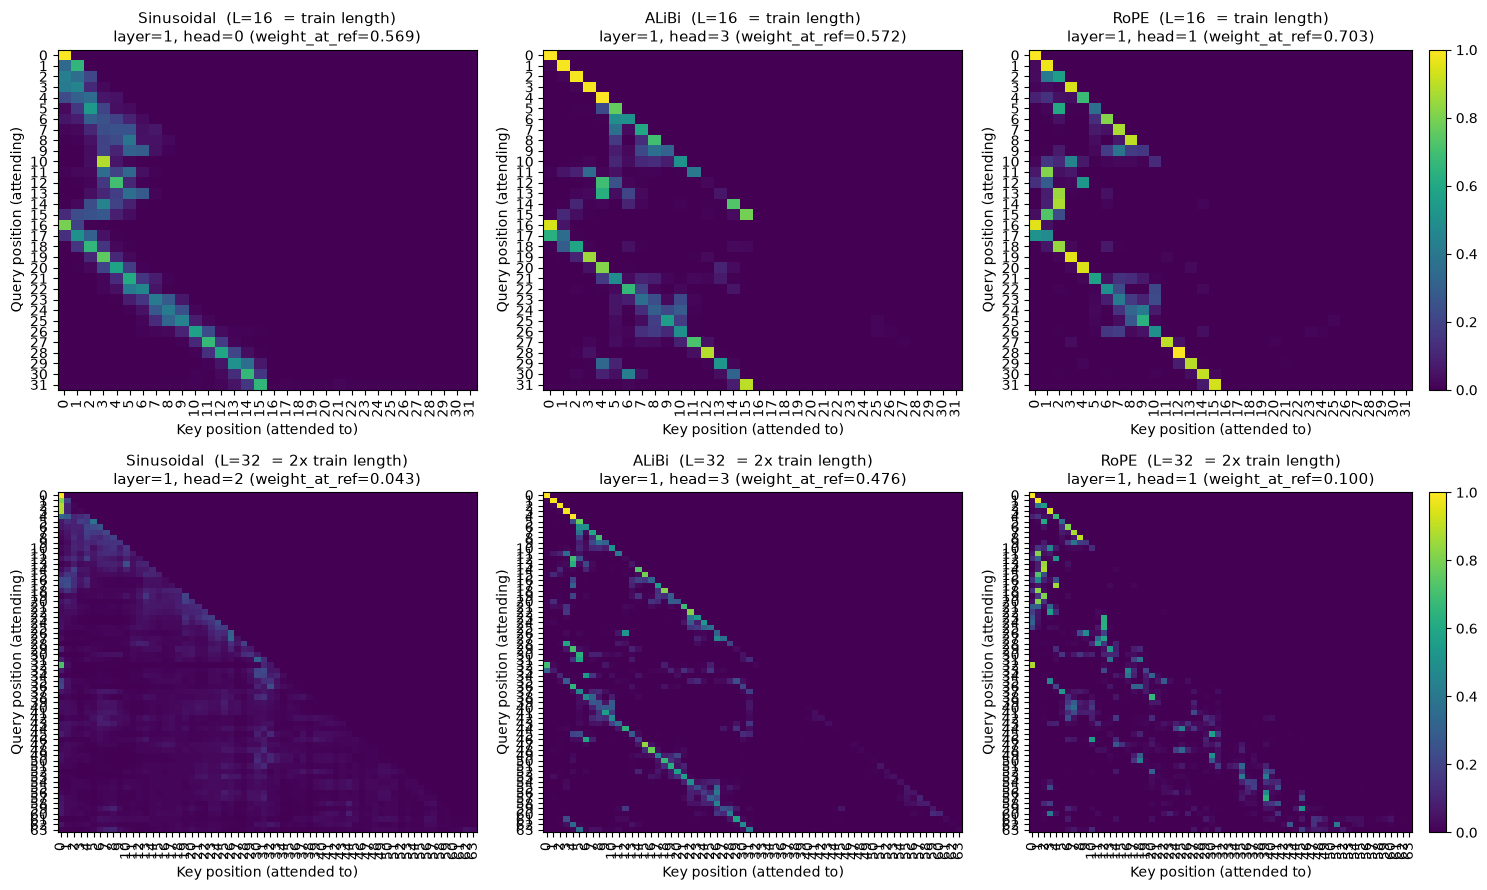

In [28]:
def get_attention_weights(
    model: nn.Module, seq_len_l: int, layer_idx: int, head_idx: int, device: str = "cpu"
) -> torch.Tensor:
    """1 サンプルぶんの入力に対する、指定した層・ヘッドの Attention 重みを取得する。"""
    model.eval()
    input_ids, _, _ = make_copy_batch(1, seq_len_l, device)
    with torch.no_grad():
        _, attn_weights_per_layer = model(input_ids)
    return attn_weights_per_layer[layer_idx][0, head_idx]  # (S, S)


VIS_CONDITIONS_C = ["sinusoidal", "alibi", "rope"]
fig, axes = plt.subplots(2, len(VIS_CONDITIONS_C), figsize=(5.0 * len(VIS_CONDITIONS_C), 9.0))

# 可視化は代表として先頭の seed(SEEDS_B[0])で学習したモデルを使い、条件・系列長ごとに
# 表 2 の元データ(weight_per_seed[0] が SEEDS_B[0] に対応)から最も集中度が高い
# (層, ヘッド)を選んで描く。
for col, name in enumerate(VIS_CONDITIONS_C):
    model_c = trained_models_b[name][SEEDS_B[0]]
    for row, l_vis in enumerate((L_MAX_TRAIN, 2 * L_MAX_TRAIN)):
        r = concentration_full[(name, l_vis)]
        best_layer, best_head = r["best_layer_per_seed"][0], r["best_head_per_seed"][0]
        best_value = r["weight_per_seed"][0][best_layer, best_head].item()

        torch.manual_seed(SEED)
        attn_c = get_attention_weights(model_c, l_vis, best_layer, best_head, DEVICE)
        length_note = "  = train length" if l_vis == L_MAX_TRAIN else "  = 2x train length"
        title = (
            f"{CONDITION_LABELS[name]}  (L={l_vis}{length_note})\n"
            f"layer={best_layer}, head={best_head} (weight_at_ref={best_value:.3f})"
        )
        plot_attention_heatmap(
            attn_c, title=title, ax=axes[row, col], colorbar=(col == len(VIS_CONDITIONS_C) - 1)
        )

plt.tight_layout()
plt.show()

#### 実験 C の結果・考察

**表 1(重みが最大の (層, ヘッド) における重み・argmax 一致率、6.3 節の実行結果より、$3$ seed の平均 [最小, 最大])**: $2$ つの指標を別々に最大化すると異なる (層, ヘッド) 由来の値が並びうるため、参照位置への重みが最大となる (層, ヘッド) を seed ごとに特定し、その同一の (層, ヘッド) における重みと argmax 一致率を並べている。

| 条件 | $L$ | 参照位置への重み(最大の (層, ヘッド)) | argmax 一致率(同一の (層, ヘッド)) | チャンスレベル |
|---|---:|---|---|---:|
| なし(対照群) | 16 | 0.1553 [0.1410, 0.1767] | 0.2500 [0.2188, 0.2969] | 0.0424 |
| なし(対照群) | 32 | 0.0559 [0.0551, 0.0566] | 0.0977 [0.0703, 0.1250] | 0.0214 |
| 正弦波方式 | 16 | 0.5760 [0.5529, 0.6058] | 0.9010 [0.8594, 0.9375] | 0.0424 |
| 正弦波方式 | 32 | 0.0583 [0.0434, 0.0674] | 0.0859 [0.0625, 0.1055] | 0.0214 |
| ALiBi | 16 | 0.5971 [0.5725, 0.6222] | 0.8594 [0.8438, 0.8906] | 0.0424 |
| ALiBi | 32 | 0.4815 [0.4739, 0.4945] | 0.8307 [0.8203, 0.8477] | 0.0214 |
| RoPE | 16 | 0.7018 [0.6635, 0.7396] | 0.9193 [0.8984, 0.9453] | 0.0424 |
| RoPE | 32 | 0.1553 [0.1000, 0.2132] | 0.2161 [0.1406, 0.2891] | 0.0214 |

チャンスレベルは、位置 $m$ が因果マスクの下で参照可能な $m+1$ 個の Key に一様な重みを置くと仮定した場合の値であり、コード内で $\mathrm{chance}(L) = (1/L)\sum_{m=L}^{2L-1} 1/(m+1)$ として計算した($L=16$ で $0.0424$、$L=32$ で $0.0214$。一様分布からの argmax は各位置が等確率で選ばれるとみなせるため、同じ値をチャンスレベルとして用いる)。

**表 2(層・ヘッドごとの参照位置への重み、$3$ seed 平均)から分かること**: いずれの条件でも 1 層目(`layer=0`)の値はチャンスレベル前後にとどまり(最も高い RoPE の`layer=0`head 2 でも $0.0571$、チャンスレベル $0.0424$ の約 $1.35$ 倍)、2 層目(`layer=1`、最終層)に copy に関わる集中が現れる。したがって、この copy task を解く上で位置情報を直接使う処理は主に最終層で行われており、1 層目は参照位置への直接的な集中を担っていない(1 層目が実際に何を行っているかは本実験では測っていない)。

**head 0 のみでは指標にならないことについて**: 正弦波方式・RoPE はいずれも精度が seed 間でほぼ一定(6.2 節末尾の表より $L=16$ で正弦波方式 $[0.9822, 0.9907]$・RoPE $[0.9829, 0.9917]$)であるにもかかわらず、表 3(seed ごとの最大値 (層, ヘッド))が示す通り、$L=16$ で重みが最大となる (層, ヘッド) は seed によって実際に異なる。RoPE は seed 0 が`(layer=1, head=1)`、seed 1 が`(layer=1, head=0)`、seed 2 が`(layer=1, head=2)`と、$3$ seed すべてで異なるヘッドが最大値を取った。正弦波方式も seed 0 は`(layer=1, head=0)`である一方、seed 1・seed 2 は`(layer=1, head=1)`であり、必ずしも同一ではない。この結果として、最終層 head 0 単体の値も $L=16$ で正弦波方式が $[0.0845, 0.5691]$、RoPE が $[0.0993, 0.7396]$ と seed 間で大きく振れる(表 3)。一方、対照群(`none`)は $L=16$・$L=32$ のいずれでも $3$ seed すべてが`(layer=1, head=1)`で一致しており、seed への依存は条件によって程度が異なる(明示的な位置情報を持たない対照群では一貫し、正弦波方式・RoPE では変動が大きい)。いずれにせよ、copy 機構がどの (層, ヘッド) に載るかは条件の性質だけで決まるわけではなく **seed(初期化・学習の過程)にも依存しうる**。この理由から、以降は表 1(seed ごとに重み最大の (層, ヘッド) を特定した上での集計)を主指標として比較する。

**正弦波方式・RoPE**: 学習長内($L=16$)では、表 1 の最大値(正弦波方式 $0.576$・RoPE $0.702$)・argmax 一致率(正弦波方式 $0.901$・RoPE $0.919$)ともにチャンスレベル($0.0424$)の $13$〜$22$ 倍に達し、後半の各位置が対応する前半の位置に明確に集中して注目していることが確認できた(ヒートマップ上でも、SEP からのオフセット分だけずれた明るい対角線として観察できる)。学習長の 2 倍($L=32$)では、正弦波方式は重み $0.058$(チャンスレベル $0.0214$ の約 $2.7$ 倍)・一致率 $0.086$(約 $4.0$ 倍)、RoPE は重み $0.155$(約 $7.3$ 倍)・一致率 $0.216$(約 $10.1$ 倍)まで低下した。いずれもチャンスレベルを数倍〜十倍程度上回っており、参照位置への集中が完全に失われたわけではないが、$L=16$ 時点の水準(チャンスレベルの十数倍以上)からは大きく後退している。RoPE の方が正弦波方式よりチャンスレベルに対する倍率を高く保っており、これは実験 B-2 で観測した精度の関係(6.2 節末尾の表より、$L=32$ での $3$ seed 平均精度は正弦波方式 $0.238$・RoPE $0.311$、RoPE がわずかに高い)と整合する。

**ALiBi**: ALiBi は学習長内($L=16$)で重み $0.597$・一致率 $0.859$(チャンスレベルの約 $14$〜$20$ 倍)に達し、正弦波方式・RoPE と同水準の集中を示した。学習長の 2 倍($L=32$)でも重み $0.482$・一致率 $0.831$(チャンスレベルの約 $22$〜$39$ 倍)とほとんど低下しておらず、正弦波方式・RoPE とは対照的に集中がほぼ保たれた。これは実験 B-2 で観測した ALiBi の緩やかな精度低下($L=16$ で $3$ seed 平均 $0.967$、$L=32$ で $0.855$)と整合する。

**ALiBi の担当ヘッドの特定**: 表 2 より、ALiBi の`layer=1`における各ヘッドの重み($3$ seed 平均)は $L=16$ で head 0: $0.0138$、head 1: $0.2730$、head 2: $0.3427$、head 3: $0.4546$ であり、$L=32$ でも head 0: $0.0003$、head 1: $0.1482$、head 2: $0.2510$、head 3: $0.3588$ と、傾き $m_h$(3.7 節、$[0.25, 0.0625, 0.015625, 0.00390625]$、距離 $16$ でのバイアスはそれぞれ $-4.0$、$-1.0$、$-0.25$、$-0.0625$)が小さいヘッドほど値が単調に大きい。

ただし、表 2 は各ヘッドの値を $3$ seed で平均したものであり、seed ごとにどのヘッドが最大となるかは表 2 からは読み取れない。表 3 より、$L=16$・$L=32$ のいずれでも、重みが最大となるヘッドは head 3(seed 0・seed 2)と head 2(seed 1)であり、$3$ seed 中 $2$ seed が head 3、$1$ seed が head 2 であって、**head 3 単体に断定できるわけではない**。これは前段(「head 0 のみでは指標にならないことについて」)で述べた「copy 機構がどの (層, ヘッド) に載るかは seed に依存しうる」という傾向が ALiBi にも当てはまることを示している。ただし、傾きが大きい head 0・head 1 が最大となった seed は $3$ seed × $2$ 系列長のいずれの組み合わせにも $1$ つもなく、最大となるのは常に傾きが小さい側の $2$ ヘッド(head 2・head 3)に限られている。したがって、「傾きが小さいヘッドが長距離の参照を担当する」という 3.7 節の設計上の帰結は実測で裏付けられているが、そのうちどちらのヘッドが実際に最大となるかは seed に依存する、という粒度で述べるのが実測に即している。

表 2 の実測値を head ごとにチャンスレベル($0.0424$)との比で見ると、head 0 は $0.0138$ でチャンスレベルの約 $0.33$ 倍と **下回っている** のに対し、head 1 は $0.2730$(約 $6.4$ 倍)、head 2 は $0.3427$(約 $8.1$ 倍)、head 3 は $0.4546$(約 $10.7$ 倍)といずれもチャンスレベルを明確に上回り、バイアスが小さいヘッドほど重みが段階的に大きくなっている。すなわち、ヘッドは参照位置に「集中する / しない」の二分ではなく、傾き $m_h$ の大きさに応じて寄与の度合いが連続的に変化しており、距離 $16$ に対するバイアスが $-4.0$ と特に大きい head 0 だけが、重みをチャンスレベル未満まで押し下げられている。これは学習の結果ではなく、ALiBi の傾き $m_h$ が **学習可能パラメータを一切持たない固定値**(3.7 節)であることによる構造的な帰結であり、head 0 だけが設計上そもそも長距離の参照に強いペナルティを受ける。

**対照群との比較**: 表 1 には対照群(明示的な位置エンコーディングを持たない`none`)の値も含めている。$L=16$ での対照群は重み $0.1553$・argmax 一致率 $0.2500$ であり、チャンスレベル $0.0424$ のそれぞれ約 $3.7$ 倍・約 $5.9$ 倍である。すなわち **明示的な位置エンコーディングを一切持たない場合でも、参照位置への集中はチャンスレベルを明確に上回る**。これは 3.1 節で述べた「因果マスク自体が暗黙の位置情報を与える」という議論の、Attention の挙動レベルでの定量的な裏付けであり、実験 B-1 で対照群の精度がチャンスレベル($\approx 0.167$)を大きく上回って $0.634$ に達したこと(6.2 節)とも整合する。対照群の値は、以下で他条件の集中度を評価する際の「明示的な位置情報なしで到達しうる水準」の目安として使う。

学習長の 2 倍($L=32$)において、正弦波方式(重み $0.0583$・一致率 $0.0859$)は対照群(重み $0.0559$・一致率 $0.0977$)と **ほぼ同水準** であり、argmax 一致率では対照群を **下回っている**。これは実験 B-2 で正弦波方式が全外挿長で対照群を下回った($L=32$ で $0.238$ vs $0.390$、6.2 節)ことと完全に整合する。3.1 節・7 節で述べている「学習時に見たことのない位置に対する意味をなさない明示的な位置信号は、因果マスク由来の暗黙の位置情報だけに頼るより有害に働きうる」という主張が、精度だけでなく **Attention の集中度そのもの** でも裏付けられたことになる。

一方、RoPE($L=32$ で重み $0.1553$・一致率 $0.2161$)は対照群(重み $0.0559$・一致率 $0.0977$)を明確に上回っているにもかかわらず、精度では対照群を下回る($0.311$ vs $0.390$、6.2 節)。すなわち **参照位置への集中度の高さと精度は単調に対応しない**。なぜ集中度が対照群を上回るのに精度が対照群を下回るのかについて、本実験の結果だけから断定はできない。本指標が全層・全ヘッドのうち重みが最大となる $1$ つの (層, ヘッド) しか見ていないこと、また copy には参照位置への注目だけでなく、参照した値を正しく出力に反映する処理(値の読み出し・変換)も必要であることが、可能性として考えられる。

**実験 B-2 の精度との対応**: 正弦波方式は学習長を超えると集中度が対照群とほぼ同水準まで低下し、RoPE は対照群を上回るもののチャンスレベルの数倍程度まで低下する(上記「対照群との比較」を参照)。いずれも学習長内で最も高い集中度に達していたことと対照的であり、実験 B-2 で観測した精度の急落(6.2 節末尾の表)と対応する。ALiBi は学習長内・学習長超のいずれでも高い集中度を維持しており、実験 B-2 で観測した緩やかな精度低下と対応する。これは、ALiBi がヘッドごとに異なる距離スケールを担当させる設計(3.7 節)により、学習長を超えた長い距離でも(遠距離担当のヘッドが)相対的に一貫したバイアスを与え続けられることの帰結だと考えられる。ただし RoPE の例が示す通り、集中度の高さは精度の高さを保証しない。

可視化に用いたモデルは代表として seed $0$ で学習したものであり、ヒートマップのタイトルには実際に選ばれた層・ヘッド番号と、その重みの値を明記している。上記の定量指標は $3$ seed の平均値である点に注意(表 3 が示す通り、個別の seed の値はこれと大きく異なりうる)。

## 7. 結果・考察 / Results and Discussion

各実験の詳細な結果・考察はそれぞれの実験セクション末尾(6.1・6.2・6.3 節)に記載した。ここでは実験 B-1・B-2($3$ seed の平均・最小・最大)と実験 C(Attention 重みの定量指標)の結果を統合し、位置エンコーディング方式全体の位置づけを整理する。

**1. 学習長内での表現力(実験 B-1、3.2〜3.8 節)**: 位置エンコーディングを一切持たない対照群(精度 $0.634$)が最も低い水準にとどまり、RoPE($0.988$)・正弦波方式($0.986$)が学習長内で最も高い精度に達した(この 2 条件の最小値は、次点の ALiBi・Shaw et al. 方式の最大値を上回っており、$3$ seed でも明確に区別できる差である)。これは、これらの方式が Attention の内積構造(RoPE)または埋め込み(正弦波)に密な位置情報を与えられることの帰結だと考えられる。ただし対照群の精度もチャンスレベル($\approx 0.167$)を大きく上回っており、これは因果マスクそのものが暗黙の位置情報を与えるためである(3.1 節、6.2 節)。実験 C(6.3 節)でも、対照群の Attention 集中度がチャンスレベルの約 $3.7$〜$5.9$ 倍に達することを確認しており、この議論を Attention の挙動レベルで定量的に裏付けている。

**2. 外挿性能(実験 B-2、3.4・3.7・3.8 節)**: 学習可能な絶対位置埋め込みは原理的に外挿できず(3.4 節)、実験でもそのまま動作しなかった。RoPE・正弦波方式は学習長内での高い表現力とは対照的に、比較した $4$ つの外挿長すべてで対照群を下回った。ALiBi・Shaw et al. 方式は、比較した $7$ 条件の中で最も緩やかな劣化を示し、全外挿長で対照群を明確に上回り続けた(両者の間の優劣は $3$ seed では確定できない)。これは ALiBi が外挿を明示的な設計目標としている手法である([5] のタイトルが示す通り)ことの直接的な帰結であり、**「ALiBi の方が優れた手法である」という結論には直結しない**。実験 B-1 は表現力、実験 B-2 は外挿性能という異なる軸を測っているためである。

**3. 統合的な考察**: RoPE は、3.8.5 節で証明した通り、相対位置を Attention の内積構造そのものに埋め込むという設計になっている。これは表現として優れており、実験 B-1 で確認した学習長内での高い精度はこの設計の帰結だと考えられる。一方で、この設計は外挿性能を保証するものではなく、実験 B-2 で確認した通り、学習長を超えると素の RoPE は急激に性能が劣化する。この外挿性能の不足は、RoPE の角周波数 $\theta_i$(3.8.4 節)のスケールを調整する **RoPE のスケーリング** という別の技術群(NTK-aware スケーリング・YaRN・位置補間、トピック 014「長文脈拡張」で扱う)で対処されることが多い。これが、現代の多くの大規模言語モデルが RoPE を採用しつつ、長文脈への対応を(RoPE 自体の変更ではなく)別の技術で行っている理由につながる。

**4. 想定との整合性**: 実験前の想定は「RoPE は学習長内での表現力に優れる一方、素の状態では外挿性能に劣り、ALiBi の方が外挿では優位」というものだった。$3$ seed の実測値はこの傾向を裏付けたが、想定より一段厳しい結果になった。当初は「RoPE・正弦波方式は $L=48$・$L=64$ あたりで対照群を下回る」程度を見込んでいたが、実際には **RoPE・正弦波方式は $1.5$ 倍長($L=24$)の時点ですでに対照群を下回り、比較した $4$ つの外挿長すべてで対照群を下回り続けた**(6.2 節)。T5 も $L=24$ で対照群を下回った。この結果は、3.1 節で追加した議論(因果マスクそのものが暗黙の位置情報を与えるため、学習時に見たことのない位置に対する意味をなさない明示的な位置信号は、暗黙の位置情報だけに頼るより有害に働きうる)と整合する。T5 の外挿性能の低さについては、6.2 節末尾の補足分析により、学習中に一度も勾配を受けないバケットが存在すること(全 $32$ バケット中 $8$ 個)を具体的に確認できた。学習長内での精度のばらつきが大きかった点(範囲 $[0.576, 0.862]$)も含め、T5 は本タスク・本設定との相性が悪かったと考えられる。

**5. 実験 C の結果**: 実験 C(6.3 節)からは、想定外だった結果が $2$ 件、実験 B の結果や 3.1 節の議論を Attention の挙動レベルで裏付ける結果が $1$ 件得られた。

想定外だった結果の $1$ つ目は、正弦波方式・RoPE のように精度が seed 間でほぼ一定な条件でも、copy 機構がどの (層, ヘッド) に載るかは条件の性質ではなく seed に依存しうるという点である(表 3)。$2$ つ目は、ALiBi の copy 機構が(傾きが大きい head 0・head 1 ではなく)傾きが小さい側の $2$ ヘッド(head 2・head 3)のいずれかに載っており、どちらに載るかは seed に依存するという点である。これは 3.7 節で述べたヘッドごとに異なる距離スケールを担当させる設計の帰結として、傾きが小さいヘッドが長距離の参照を担うことは実測で裏付けられた一方、そのうちどちらが実際に最大となるかまでは seed に依存することが分かった(6.3 節)。

想定を裏付ける結果として、学習長を超えた $L=32$ では正弦波方式の Attention 集中度が対照群とほぼ同水準まで低下し、argmax 一致率では対照群を下回ることが確認できた。これは実験 B-2 で正弦波方式が全外挿長で対照群を下回ったことと対応しており、点 2・点 4 で述べた「意味をなさない明示的な位置信号が暗黙の位置情報より有害に働きうる」という主張を、精度だけでなく Attention の集中度の面からも裏付けている。

重みが最大となる (層, ヘッド) における値(表 1)で条件間を比較すると、ALiBi は学習長内・学習長超のいずれでも高い集中度を維持しており、実験 B-2 で観測した緩やかな精度低下と対応する結果が得られた。ただし、この対応関係は 6.3 節で観測した相関であり、集中度の高さが精度を直接決定するという因果関係まで実測値から結論づけることはできない。